# 21_因果推断基础-LaLonde 综合案例：从随机试验到观察性研究

## Notebook 使用说明

建议先阅读第 04–09 份笔记。本篇需要 NumPy、pandas、Matplotlib 和 statsmodels；缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

这次使用真实的 LaLonde 相关数据，而不是模拟。实验样本来自 R 的 Matching 包，包含 185 位被分到培训组的人和 260 位随机对照；外部比较使用 MatchIt 包的 429 位对照，该包文档将其记为 PSID。为保证前后比较的是同一群接受者，两套分析都使用 Matching 中的同一份 185 人记录。整理后的 874 条来源记录已压缩嵌入下面的数据初始化单元，读取时校验 SHA-256；无需联网、R 环境或其他文件。[3–5]

参考资料 [1] 第 3.4、4.5.3、15.5.1 节的实验结果用于数值核对；观察性部分使用第 13 章的 ATT 方法、第 15 章的匹配及第 18.4 节的敏感性思路。[2] 第 5.5 节与附录 5.C 用于对照 ATET 的定义与识别。需要区分：这里的外部对照不是 [1] 第 15.5.2 节使用的 `cps1re74.csv` 全部 CPS 对照，不复现该节的观察性数值。模型规格、诊断图和三来源联合 Bootstrap 是本篇的教学实现。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells；不依赖前面 Notebook 的变量或 `notebook_support.py`。默认包括 4,999 次随机分配和 999 次完整重拟合 Bootstrap，次数均在初始化单元设置。真实数据没有一张能打开查看的潜在结局答案表，因此本篇不报告“真实偏差”或区间覆盖率。

In [1]:
# 环境初始化：数据已嵌入本篇，不访问网络，也不读写外部数据文件。
import os
import sys
import tempfile
import warnings
import base64
import gzip
import hashlib
from io import StringIO
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display
import statsmodels
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_FRT = 2026
SEED_BOOT = 2027
N_PERMUTATIONS = 4999
N_BOOT = 999
ALPHA = 0.05
Z_CRIT = NormalDist().inv_cdf(1 - ALPHA / 2)
BASE_COVARIATES = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]
CALIPER_MULTIPLIERS = (0.005, 0.01, 0.025, 0.05, 0.10, 0.20)
if N_BOOT < 2 or N_PERMUTATIONS < 1:
    raise ValueError("Bootstrap 至少重复两次，随机化检验至少重复一次。")

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
statsmodels 0.14.6


前面每次都能把估计值与模拟真值比较。现在换成真实收入数据：培训组的收入比随机对照高，但把对照换成另外一份调查中的人，连最简单的均值差都可能改变方向。

这不一定是算法出了问题。先要看对照是谁、两组有哪些差别，以及我们想把结论说给哪一群人。然后再拟合回归、加权和匹配，检查调整之后的比较是否有根据。

下面保留同一份培训组，只换对照来源。实验结果是有抽样误差的参照，不是用来挑选“最接近正确答案”的调参目标。

## 理论基础

### 1. 同样叫 LaLonde，可能不是同一份数据

LaLonde 案例比较了就业培训的实验评价与非实验评价。Ding 在随机试验章节使用 Matching 包中的实验数据，又在观察性研究章节换用外部对照。[1，第 10.1、15.5 节]

本篇实际读取三组记录：

| 来源 | 人数 | 在本篇中的作用 |
|---|---:|---|
| Matching：NSW 培训组 | 185 | 两套分析共用的处理组 |
| Matching：NSW 随机对照 | 260 | 只进入实验分析 |
| MatchIt：外部对照，文档记为 PSID | 429 | 只进入观察性分析 |

实验表是 445 人，观察表是 614 人。两表相加不是 1,059 位不同的人，因为 185 位培训组成员重复出现。实际保存 874 条来源记录。Matching 的实验样本对应 Dehejia–Wahba 使用的有 1974 年收入信息的子样本，不是原始 NSW 男性样本的全部 297 位培训组与 425 位对照。[3–5]

外部对照直接沿用 MatchIt 的发布版本和名称，不自行改叫 CPS。另一个小差别是两包对培训组收入保存的精度不同；本篇统一使用 Matching 的培训组，因此整理后的观察表也不是 MatchIt 原始 614 行文件的逐字节副本。这个选择只为保持同一份处理组，不进行随机生成或补造收入。

### 2. 先统一目标，再比较估计方法

令 $T=1$ 表示被分到 NSW 培训组，$Y$ 表示 1978 年实际收入，$X$ 为已选定的处理前变量。这里沿用数据中的分组变量，不把它另解释为“完整完成培训”；数据也没有提供完整依从过程。[1，第 3.4 节；3]

实验分析按书中简化的完全随机分配框架，估计实验人群的平均处理效应，均值差与 Neyman 标准误为：

$$
\widehat\tau_{\mathrm{exp}}=\overline Y_1-\overline Y_0,
\qquad
\widehat{\mathrm{SE}}_{\mathrm{exp}}
=\sqrt{\frac{s_1^2}{n_1}+\frac{s_0^2}{n_0}}.
$$

观察性分析主要问：NSW 培训组代表的这群人，如果没有接受这一分组下的处理，平均收入会是多少？目标为 ATT：

$$
\tau_T=E[Y(1)-Y(0)\mid T=1]
=E[Y\mid T=1]-E[Y(0)\mid T=1].
$$

第二本书使用 ATET 表示同一目标。[1，第 13.1 节；2，第 5.5 节、附录 5.C]

两者不能无条件画等号：固定 445 人的有限总体平均效应，不必等于其中实际 185 位处理者的平均效应。把实验均值差作为 ATT 的参照，需要借助随机分配使处理组在重复试验中代表相同试验人群的解释，或相应的总体抽样视角；它仍不是已知真值。本篇不会根据与参照线的距离，计算方法的“真实偏差”。

In [2]:
# 数据初始化：完整 CSV 的 gzip + Base64 表示，只为单文件离线运行。
# 内容来自参考资料 [3]、[4]，不是随机生成的数据。解码与校验在下一单元。
DATA_SHA256 = "0062d70e291d66052230cf2a5f23c4ee4daa861d3c6cc300e2341e9bdd6de42b"
DATA_GZIP_BASE64 = (
    "H4sIAAAAAAAC/5V9y64tOXLd3N9ysMGI4HN8PNHAggEZ8FAoV19IDcndQqn0/47F5CO4N5l5jELd26gmuZlkPFc8+Ne/fP3n3//r"
    "j99/ff35x6/f/vz67V9+ff36y3/9/vV//v233//t61//+p//8dvfvv7vb3/88ddff/n629//8utf/vj16+uPX8njj4A/8n/7x3/6"
    "3//8v5yjr/o/vuhL0heR/u2+6p8vV/8tRfSv0IfzGM78VepYZ0ZLKOGVSx8tc3EdxXVw/acNZ19ceY3F/Vx87MWunoKLLxrDw1xd"
    "vvLHaM7llcZW4rrx98HehfjyY3Sao2W3cf23D81zF7zbdPaJXxT78GL3QfHzSCj6l+M2nJz9Rt1IW3sMJ/aUX9SHz9uksvnKTEle"
    "ZYw2l6kT5GMvlFzxr751mrdJeXPe80xovUj3QVSUk5RXP22aF0npK30sLI7llTvFUrTf2BZfhjPnQVOUlq1svtGHTHMrebn4z8VT"
    "LPLyffS8TL+lb3LZ+Ze04Twvk+N+ePJprM607IVuDpznTXod5/u6Y2ggP/mMDVvmysTrutG7/CpjtLlMv9sGlUJz08ESyeYAiSjK"
    "q9M3G7YsW/ETvczPNJcZdlspuaQprDi/keG7tNK9eB53z8WS4W7rkZXX+mbEPZxLUVGY+mB6WHvepZi7zF/+Y2QMgV6hb1pkcyQL"
    "q4XkX76ft5jLdPeCTcKy8udQIb331A9b5k16Bgl+CDYXXBiHLctVhs+vJOXKwfOSN/LYisFQSA9l7MXwZWySihaBomJtiGS/XuTd"
    "3XhaJOaGgzn4V+jb9ryK43dGI6GcX2O0WBr5lK/ZRZoqyvtVGl9faLRfyulVxjeG5d4/iVWKaqnQudjHB6oyR5Lud21GZjuy3I0s"
    "98RByodTTgb3oKx9VhlC/ZiDucN7NRbm9Sn/bk4hO2yj30hY9OOtvA7+gbdYvIrgLj1CWOyoz42E4l4pdyYP8cfCJiRr/n3eCbmY"
    "XqEbDCFbNeM/tpE4+1cZ51E2EmGxXYSwehse3WIZ0Se3KAW9fFemkX5Kd5Gtjskb/aXmRenUFI1yDLvD8zHGF4/hTzZrUMXLpRNf"
    "DHYvfmNeqD4aFm6MllS3t1OmeRHTw1bMkSzyNH0ctRlpLrGz4sICwcdX6pSX3KLOP60ttW/KK3aplMju+E4iJLYSfbNwVMOJh+ZP"
    "CyvGu4WfOJGoxDBkdAr2Rih8DC+h5ClH07sc/aDpnPK0J1NaWGCzmRzTtPZTttro9vhWQ/WTNFjUnRqWfn5nxQ/t7NVb6tIp08MR"
    "zn1kXkTkTu4xvah/YF4M1eb9LJK9eLUS+q1n/2Drm40EO/ROeuS47OGOq/LiNeZP5zirTcOdlHJevIGNXZ1YaC5e3kyP97PIEI/9"
    "Bouzd3L3fYUelJw6SG76aoV/rFuKPFjrZqh/sKtKUTYZoEWZt+f9w8rxjTg/PKOQpw4qydLnBiXwmSe9lbwouB28EQxeURar5u7o"
    "yDl7KZ8wC0f15Ptlk8FwHgxYsvhN3A0trNKuoybknq7Q5/Bi6aP9gwHkM/lXHMPD4shv4B51zYcwIIPgqKVc7j7yyecXr5fxGvt4"
    "sEupBHVYUx9dNrbYfh/kNodN1QTn/DmarIk+txFVDKpRdfE4JEjsWyFeN95/wPvwApCipoFXG0a9VmcmycEDVN/5pXSlXq5eqZ6J"
    "2dnpXrPejzo8yrPq9KglVLioz+b7tEXGGqdNYnIvFZYi/gVb3/xSPAi59ynqZ4U8p6XNL+Ef3ZhqV1hy6gsFVWbAHvq9W6znwxeW"
    "pFJBjR89DX7F8UnlBnsS8ILaE5nYD5OI+OSdBICZyt3BqZDXaTHRS2RMo8WSWt3pCCNKbRxKmcI4BeYb6CWpWVL0VkuSNEQSGSTo"
    "Ay/sMyhFfFif8a5jO6pSRElT3YmszKKKy1zqGyQ0jSCBMaNDCxX13bOytSr/1PndQkOdLbteKkoGSuW6tyQD3CA+mU8hqnGjKr+I"
    "imM1sszednjf/JWo/gZEE8skGwMTcYNkr98pIIAEfaSyWfVSCEX/6tMsXLTIDYl6I1BNrBQO8a2r+E5wK240L4gSRfXLwAdSfws8"
    "38/BIEj8IYcJPppea3TiUlfrZGGk+G4FkBRoPaXC6F7Stc4blDR/RXmM1BLR4dUb/FIfRU9vfFHYwGb4MyvXSAbHqX9FMFSFJzUY"
    "eEnebV2KSqrqD6q6MuwtH9aY+aJEolygalt/Q8Zv5AMDdTGi/OZf1bciPyBPMmgTWHWSnV4loGVdTAmCrUT17u24rV/AzLH+ioCg"
    "+g35RcnPA1BvUaWNTsp6BhlYhzJTvyMDQK2mOXmvP5J1KbXt2HKEQaFWY8JzcC+V9V6ZVGWpXpMbyAAZNGogbpW4oU3UjeVQIBPt"
    "74TF7lwNM46kljLrj+mBd1iPfDwYDOq9qBgUTAs4aK9Dh3VkAap391+NnfRSw6IUVS8x9xn54Egri8aX2qpcIYDl1MoN/3DSK1LP"
    "n5XTedBnWAXCPOgAV0ylOyfVQUr3AV9FnQ5W+OpNynOWKhZEnVYVxn0KL1dqqEASfFud5pXV4lcEHjOOIcj+4PQzVHHp5xQVXPq1"
    "KUgY+AlZaGvRd5Gj2lxerSaEfpRIcLc8pgVrS6/SXm9XfWospkTkO8mF1bKfVp5Ka6AoQHkdznHeUrgx74XVD1AJoOrYTWkV8sEx"
    "iV41j/KbqMqGaNCzUDU+ppVNAKx+kFNtr4JHVPu/FiPLwl9kTrubZRKLnrIeDnR/PwMDgi1RTSZIbJ0EelARLF5PZEiFuOCa3phz"
    "Kqd06x7xNt1EEvV2BvfFnWComDMlp+N1GrCJYL/JL5JxpVXVrIgy2eHhIEhLUtdWxazP+gsFP15SfI2NvQcErTANomoF/KjfUoZM"
    "iOlNknT0PHgdrswcvGoSVZJJpaofs/JeB6nDoQcHi07/UhVeYJuO3a0BX3NsPmawkQ7OEJFU45ZdOiS3x3aiV8WvIi0klfOqtZNq"
    "pjiM+3QKMynr0DWtCFR5CMzTzUu8CUzi34xIoAoGneZfWVkMxzNYPcnqsYxvUwWmtsyXetYqlsGbeh7DhjaI22pDe7o0S0QoPlnC"
    "sKjb4rWqWtFbTdc9qUyJKl9zGqcRD3YQYZbqi5iVaXO0v/RuQjYp9OWVoVhvPbmgwhl8DA7rs/ISpV8NrpRVqBZW+afGwDAHU/n4"
    "oSZYkpqNyrLZ6w9BZ1dsv83K7o2hLDCQYXorZQe1V1+uiwiDzskSOoMTeoHIANGUqUKBq9OnrZbDBO8lOO9e4PqgsiWqXAL02s8v"
    "L+j5FONqvznGj6hEcrANGYHxMcvbWdnMSipdQcvgd1anLMeJH+SwOfXGWUp/ahMFhHdVMCGW2Kj2u2e8fOMI5A4t+e7ZLnVo3IFH"
    "qmqAS/XhMofzDULx3TNdMJL2wH7CIffRYYz2WxRGJXDp8vC7p7ocFy/MI0j+3VNd6qZ9M5PXrYTYsZLvnu2C0eJ3aGEEdcg462IX"
    "9ztEVAVFX7zhJXXxeH8zZC6RdtHmkCB7Yh9uLjLf3gyZO+y5KLQfae6w7LB9M3ReoArKfPfzcTnfDaRIJB1c+O7ZLe18t+kqNETv"
    "d89uaQT6CVCXoj5o6ZRB5vL24B+sTMltOJvbK7dnzGRPrnwizjGGPEiO5915vyPnpKpsLL1c3+dJC8ItsZMFe/uFm9FBLe8yNjJv"
    "ER7LJj8kOerpUt89taVfpbshJU6WmtPHvZiRhv+2se4AT4bHHooVBbsMmKzahroAE/cm794jthEpH0OSCi0H8rmZGg+W0ofPizxE"
    "Vr06I9Klnohlmpuw0nfPajlTqhkalqEbjhFV1258Ylz2fLtyWvb7uTKrHBhCWrLdxyfCr76KHvU4i2LJeptVpT6Y7/fo3bIV+lhd"
    "HdE8pYin5do3QLyaUt0D/e5ZLfVM8q0087JhgWVhmByhH7ZfJerdjXvDi7zZQ1Kn90Wdc3205/F52FkAXI/jSD82EHy2R7G7F/bc"
    "g2ffPa+li+s7agpu2cQmr8BlmOZ9ONkv/JQgXpKfVB140Z4bgyIg5NG3HeSBZ8y2vdUwu2gisLp+LyE8fKRZOC5HtzHFKjowzsPc"
    "YXlYOT9cipqTHF/j7Mq9kaeWrX5hHx2dNTx215hU3AxCjfQgr2NgOBN9+GqfblJhi1DHWL57asv5HlldAX6N1f2DcTHPMAa7kXA3"
    "Mj7YeHra6vCMLacNPR1WXiTqLl9xZkp/97yWLlF3NjWVNCg1OUtPdzIv0RuhnoVY4uXj7g44iV01bU5NvcXYGTb5hfp3eSR6xkOP"
    "p/CmPt9zCT3CvLHTRTJXuM96lkgyrjCl1ej82LqUASR/95yW7xog+5JPfkEuXzc5U3lQublm4/SNZ7dxXhb6h/07RtNyO3cXmdlq"
    "I4MaDLZNqp5lrCwPhqRZ+cFRNCPnJQa3Ex1maNyYS+t9v1II3VTJO324N2Tzkz40Q8tGGC1JumpNv3KnizLvzm95JaJOZTiehawz"
    "srFkJZUw6KjwQhjymV5MRfVhP5DywIyM0aGLjuIX4thKGiW7sXhYBNMmhS6iZKbTUokPKoBV477c2EyyztStPC35wagmjr4nf3z3"
    "7Jaz+B0r9+yWrhQ/L8cMpeXwbgiK3I+lKRmgZlsmExKNoP83GbBmsivtF/6xQUMGpZGnoenR+lc/qyXLf5PBaPY1FXpU3AOL32Qx"
    "mntzlwxAw2HjuHs1u1+S+mh6MjdmgdY3WYjGP2xDLP18QlaZYEFwH+0th8RdUpIMOIwMVAPl9pm0nESlY+xnTfFBipldp4drMUN3"
    "psyeQSxIk+9yHr+Jn1wKL8H16rBvMihN2IqKlJVLuiAiA9MoPYez+iGWezRMIk449tHegp+blLyso/t1WIim3OT9fhPHDdRxOLcf"
    "+4Nk4JkrEenDS/Gp8GA9A8+INL90TxHifkxnsuDbOwjM99zdbzKYzLamj0LMPV3omwwks825T4id+i43xa9S9hP8JZqcZICZUc/y"
    "BomXnt/6TbJg3DtaRmSfx2cmu/FdkWYtqpI+PC9AxAapElemwDXozH544DwcSDLgzB77Z6+jO1t5eooU5JTm2vzmP356eOrf5X6f"
    "frnP3XCcYuoSwS/GaNrgwcK9+OmbfHi4IpXjTl5j8fh2iGcBYgCae6OYDD5zn638TQabOZyFOk09fvdNBp+he4CBDDZTueYzwsJE"
    "c/TTFVKtg+nHZrCZh7Mw0My+vKwgNNw5xkAzBEn6fhvBIXTaB3/e3ZvMoeJ7SPKbwjs3uvOm84rcfXAWTG3X5WlY7vDuMAwuc7jt"
    "FF5hKKFI9wvLDNJ+k0FlnkgjykZyLKYap5Lmyv7+NNghE6cfcwz3pMGiBD3kb3ySqGbX6e3wPvBUrz4Hj5Xzz8/jiQkJmXg9okDJ"
    "rdfyQaQ6fLiQlOiBsxLKMzpaRmkBSefxBWRStHxsEd0Od1md5PADyiBwH1tBMwLh40f84WwImGPkt/OxSI2NhTHyH0IDWH2koScN"
    "VsPZQjuCrgRX9s1XTMrLcXxFOvh9AQkM7SvMlvIauxqZf5KdEVlk9lQW33ylB4TnconmB/IaFV4tNQT4pSQ7/A5/UwmhajvY4Xyw"
    "DN7T4T2rhdCBWsqnq9brVdcjIbHyBcdNfZyRsf9NK5zznryX5BVUnqsp4qcXZXCdNd9P1aBeR0EW9SurpeeRjd85w0I8I027pkIj"
    "Vx9ZX8m/grrMvhrxnVUN1POZlOmBr3uxh5fPWDiy233NM/YvKmNf5Qb6CgzrEYnDFeVuU4rbIBy4p0hINUhIoHqlZPdV3oymJSFM"
    "SSAogSVxA3QhAwCtrlFEChyS9LPK92J/4i46CRGRkV4MeutoPRV/YybWY1IVbX7hZD+Ri8j4jcj4ViEVfEm9H4DOijcSNEZfixrM"
    "j6Q3h8V6mimAuezofADNxUWkqH4l5MWWZUp5w3osRWWHxHCBzEo9h+ib3Slmwl5qglhWaepn7qTOWLNB5kfHqLLQIaYZGam0UrwK"
    "mNCn8UGP+eL0cwDWqfdTqqEaeyiAbZbPEi1VpVcTW9XTv/LekY3WOrnotAWTf0tg10WVh5FEqi7O2F44bK8OR747iypwuUKBncXY"
    "AEtryCQVZX0gBCizQE52lDKCfLzmAb0XDQgYUrftywCO2OUDCwR1GvQskL5Vkw51ZBmGPrs1J+FdnuvJBzJ3azEnb41FjmpkoAim"
    "5lHmmv1P3VTiNUFoigAuyOiESlaKw7Ei0arfkcGg5B2ZUGMj4tTMzlYY3zCo6tOa958QNwx2ij9dqVdFBm2TBCyqcif4EXFnCnu8"
    "MiN7P6IOSOlGzzVRovlb8QbuUUEclTZxVdJTfHVKOoQ8vCBVkPUmXc169iC87v8y5UO4iRnpJR4E4JBQrPZdModRbgBbrkwUvwLg"
    "tsFEvIThDNqVKL9YXThG+aI6DSoYZ8CF14QjyxLKCeIhWVSYqvdQUuJhuDLz2epnNLoyJQA6+mj9tVodtSaQk2CnnBIesq8JxYx6"
    "SQYdTVyOeUkmi6ZOUAk0I5k/OEgH8zMnqJlcQGclGCnIf9B947461RncS6LNIglerV7lPJWK6MsE6eBHFgfzKW6gri1d6fx6yKhv"
    "yKiKGIddDneEhFP1HZGgHyqLEBkhJG6PdulFepSCiFeKdZZthQ4WnweV4rOQTOnsPRmUzMuaf+yQcIzU5YwyrBRgLXYZJDtN0b07"
    "D8w+Lb/iN9p1DPewKazSk3A4sCiCriRfPnx8etxo1lp7FSCgwW36t84ssA7HEadDuEbJR69E6QHgGew2dUPMj2X79fNmiFDeVHSW"
    "6mRVySDBQQVSblLKAsLKxVK2P0HaKdJVOwPeg7h3nAZMzJ4OmkvFCOPolJfq5ahZUkaeFHvemOJX6ZoeGypt9ZZgmSDJJQ+tYrOg"
    "llikWl96fqKGgssvVQ3qVap/1anHoG1LQYiUkJDdXGeBCbM5PwO6rco/Z/CezsLV6hYluWy+LL4ljI1pTjWMEkZCxZOSX4oqIHhM"
    "S295RP1I1AZkVOxkBNQvC0BtgrHJvNzarKAMkMdJZ0VUY32lWlAyZpW9AVU41qKQQphlbE8O7jPrt3q/TkX7C+XKgKvDZUflLr8M"
    "XPfZbKcINLvXS8g8vsemUy3gPAlcmjoLpaB2a3LixF4FqZoWrGim+Dd16abzr3Y9YmbIdkhftWlf9zrYAHkjfZZMkQbVq4G2lzDy"
    "vNmmW1nwAw2rIn6Lpc4y20sHq10VuYouVIHAHLQCL+T1RvvBFRQLSi0k9YStxaK+2tha2QchlRrVPYgYjeo/BOqkN8D6ZpuINU6v"
    "TgtVu6KGULj26/FoyfU//+kf/jt9/Y/f/vz9X//hz3/+/e9/+/OPv//7yHhxo4aClC9ghGZBAxpVairWPBx+LMCbBWYhQV0gZHgm"
    "0PFZ1bde1rKA7BZA7eVmgSAq6pjWBfxmAT+6K9XvJzQKQ5WOh+0EsyrgwhzVBcJ+B4aOfC2sqtY+irKuC8bUuDu+tBaFoNYZOkUV"
    "Z91DyoLmgJiedtPZHh6V2p0K8yPMPXwDKj/5ur682/oq7lHYLFTJuSDDFZZ0rB0tsEDZ7SCbOJ26h6rLqhfj9BAoj29XAtvMLZbw"
    "KCL1z1d3DhnsrPwptU9ZXWBHfDo4zPkO2iPBsEADRhxD8aqI5bo42hGfjOaQ9fz0tCuERBWgjDCfq+y4aId21CfelFKr/668kkBP"
    "Hn0ug3KPioekvmhdYEd9l4cwtuBTrFWAKKmu9B+9smPiiwZoS35LM7FUm4LB2yQVgMCDVIerblOnpq4Q9xwwTvGrIuwZhrFDWVhh"
    "lEHwq4i/FkgnDpjmMDC/lKo9VHAjSe0otT7aRWzpsMNSVwGlA6ZcC9hRjwxm9ioNUiOFHR2ijdNsviDwZmPFPsQpLeBG0BGxXIfA"
    "W2oMyxZ8UlYUVVV6GmozY1O1IPZaYEeNs6dm/SfA6VWTqzjkv1ZeQh2pv06Beb9CHAtUYgRAWBBaUkNa7T116NV7uhbYUuObMEUl"
    "sv6HjFrZUBIysdD54SIm3grDZOrNCqI+CELkUAv+y+BnDoc7MILUwUZC/RqcAhiLqy6I+wNIYwEBrqeWJMInQK0uplDDoV1i2h+A"
    "laeMJsYoHdQ7zH7uPu+l0Tx8ADwFtnX2qnJVUcO1QQvCiwl4R4IDV7kIiCDC01yAmFBFfC0g7lkUQI4BkskOnUQoju0LHaSADMsx"
    "Qv5kpd+UMwpbv1QUqvNDTY3yQY8aaSwRyIu6cKiQ5drGI6I550U7IgcGMPtXh1kNqqIrwGbWj6sqXbXjtcKW+oKRpqx+iTq2ShJR"
    "yTjBUAjI35b2EeHZmhBgwkp51Q8t6IiQVUInuvSZxMePKLXgGXvwcIIz9AWEfLvFLQna5hqqSFF8irrk6kKiCBPhDN92kA8XYckA"
    "jWR0YPJQjwIUXS0c/aJrha0wLGYL0asdm+oWYA/iHuAIq1NxWURuz8kyBVFQO8bnoAvAU632BQGDaAucqHE6diWhKhl4uNSuqln/"
    "f1xkN8oO5Dh1e0LUqEA6wLNMoEYPj7YvID84xgDUCSugJwpMj4JC83TdpPd7hrYrSFRVgvaQSBrxQF4cUofcdZU+7GnBWEf6i1CD"
    "6pCoJsk5vZmm8dY+q+cYgmp04Cqouo4N1KqTd5Q4yzCpNglDBEq3rS5v1h9VwSK6jaZO/JkSR4E0MoS9yuOIqgid+FXlcnBt/+VZ"
    "pAVkuGSsgDpm/T9RDoRGVpdt7Y4nMBU72lzpxFitFNhHESWz7hJLgfZ7mIJdNRlXfR6RTo3gbqq9QZqNHE6SUYyVzTVkpr8c9BhA"
    "SYJKtiYZg+wNVQqfPkqEmSnwkvxVNF4X8I+mskpWtDTTj/DIrF7pKBwI0d6DCrJS0Q+JCNFk9C5BE9eLlEPcn+KUKQVJ1DoXuDxX"
    "1cwuqK2QL5EQ0oGbyFjraNqFFgWs0gXEBHMTqNG1Qj5Y61a44/xhMtX+9nqcqjBAXs1RK0f7aOAyhOJsX1e4dHRiQquZS0NFt6eF"
    "aaEEFegqUdGiQVV1rMTOrxiafom0NzOT9VnQoUfQ1E7vX9WDiik1XVNbgPeidZoZIWapxnqEVkpoGqZSWjnkOsYo+2PkmfegruIL"
    "KQgBbV2VvdARTYmzMXX0BzsvGGJSA1VpR1fQj5eM4xR0n7j4IYa9lSmTmJzSfi7+alqu6gqRbNBS+4a41/MzJVIQlkR6ZcgIV4SK"
    "iUvtNFkXSHuXx15DQfZWQVhbBbqaWkVtD1Wa7RN2xBjERm/VKnfAnGqZfYCZUHCeTUnHckBO0mzSkzKnK3rv4+UueHSWaqSU3N5p"
    "shabg7mkWkRX8BcxOmSUN4cjbR3ouPCk+jyCIEFgtIMMYaiXxIefnyeQYWvD460NeSKAFGT25Euupjt7saF9KV6BjQA08jK5jVhL"
    "/tFm9SJoa4eOH2oyIb/geg2kSYQU9viFsdZQngqREhBtQ4H2OIB4Y2xeJ5gK4q7omEQoSMnU+mzEiwbSjgrDUrqZkFuD2ubg1Ggs"
    "bkJHKZ+33rx2jq5GMD20O4yLDBzPNSZKW+WMSOma0pIhjKFsIl7ecA04cvvJ8+DqMzeAVn1Wnw9yjFPtlXRJ0kyHX7f2Gcoci66Q"
    "8N4LQDCPJIrr+zPfGHgX+WTYYkjF8+gZDiEgiFWo8XqtcDIRpyBLAihXVYRPkF/oPageTEBD+7qC3+N3Buav7dZQKORTjcxMfzmf"
    "/GVzAvnKP1SmhJ8F6JMARbvrBnM8WHgT+A5okJYTVkBEEbgm8h9Dv8atHMxWDoqqg5daeB4tzYpMAZDz4deNAAjoZIMnOiI6N/Kk"
    "3rwjPgjZCdkDIGK0VIfw8PN3y8lPnlxfWxcmpHDBtAPlJCQupvbV5YRax9lM1RVE8QE4xlx/HvXe+dU81XLQwkZyKtuo/sAbAOiT"
    "Vb1lF3U3jf6LHFaYd4fcCBCdruAQroZNCI+dL+lRDljNElxBLEZlkgdkBeFFRfRKGuJQwiMLqQyJFb70yBxBmFxcjVc1+Dfe7qH1"
    "WVN5K1hBbbmqg4oXWOzXClu70C8dtpCAkdQM9/D0IMMHKeRH/4gjIBquXeHkZaioHNXX0L8RbVPUhvDoIKpmgIoD9dNVCjb82h0+"
    "fibg6CTkOvrWRVMZQNDoK7fjQ+3eRgMYEtCTrK49Ph4P6wB+fqkO6fN3dEiLElY7FqYUOtGoAgSaUtDptwOnTm693NpaLkLoqt3o"
    "1Tq+LJmIhuCxob/O355DVUWi1hMyLrwrDS9I9SAaAu3C4y4YxhDyTeozZPAOAporBteXiHso3uziesQMvQuhaPQQZyjBpVthhjUC"
    "WpTiGATNeGER6m9GiPS2xI4Yvbd+Ykb8rCA2iq6nsOgENmJy/SQPGKLRSLEgkUB1t1rVl38x4inkHqM5AU6JGrY6G4KxxoqQF5Ta"
    "N2xDKoEsSYOdMpSqoCgQtj0FVvpoMoXoZBfaBFuEoQXvqaiCR61iAYcF7kvIQSaEaVwzdDvaNqK7H5DweQx+v4FpGGX0QlW9ppMp"
    "v+zUcDjBSUMhI/BR+2VXnwjWskvDrCeKPwjooBGtKgAB6Aa7uJKib/4V7cMpq2nkEUvFPaLbPiALvQ2k1zRmoHz8kKWhp8+uXmFA"
    "0mKMfXZ58o58bRmp0keAo9cbzKFaSi2wthWN75+gPjrVJaT66njoA8/MXSucwimTjCgiAoTOnagD0DOoiXClYcF0Cqf4QQeoH1CX"
    "zKPthatEJMgU784+8TOGyOjFgca1gqxM6KZUUALgeoTRPwpoDyQU/ITzqDIPTlIXa9uoSg38f2JHgpe1oKcWL4n4GdP2DokA+t8E"
    "ICwuIyE7P/frTIevWOuSBF2ZUQhEob1icM3Oe3ZOBstFo2S1UgUBkUWocXlkhgTSi3FOrjGuoZ62cZWw2tkFYU0sgbJoeLlo+pVe"
    "XbRvoyurqQu5qp8P5EENbR9qgBJNgNsh7OMrsnjrAdWeSMgjf8XmIvq/hi5atgGWsAJgtXmu1CVcNdfU4ya8WnOt4I+Q8KhgiS6p"
    "xcLoKIxQ21fxejNdrshJQDoToivorq0yL7lqb3DtBJ77OcQbEdsyozK8ZuUIru5zQJTBjSgpSXq0FTJyDUupGCaiDJOcJD8iqVfZ"
    "vfp99emhavW2uQf4MMxu/ZXs1TngjKb7AFETima5ceI2sLKkK6OEFzc+V4Co993voG1kRUXzRLNZrVW9MexBFVQ1t/VGxw3uAyvO"
    "PHCl41F9hb2XC3KICFeHbjHuIysLR6o2UUGs7imjbMoGiWkbVZE1LgORCsJJePTATA2PsvR6+8MhkRh2ZkVj0DmkJ3xsAyp+ic5l"
    "AWqKBubJV4dZmVAZqAv0bVQFLr/JGcl4r0Jq9UCuLrMyHgP/aUsc5KGFrfDpGbtAlLIC2XiWNnX9ug2shNVedunqWM7wW2PNvSCk"
    "wrcP2UdW2DJikhqnRsaWCtQKRXu8KtjthPAsFqU211bO4UAXgJIIeeiu0fM2uBJs7kmqz/E6HAWCVWECcBSefRcuMLFErneGYPd7"
    "5HLlnrmyjays3dMKXjSAcmIPg9dAoLSPq7wHrNWyqx5QqQZ3qakwLVBK4SQOZW32j5iKTVegbTxleRqYIMDRyIhRWo+QNyE5WCmh"
    "rZAP7ORMKiOEl2oNRiI6zj7jKQVXOgE8O9ERKelq2egSIXQnGgzZ9MEpokJ+osCRgcAKIsRIo/MozWDEqNoSdAOktU+RSDAVGXGh"
    "gu9As+Thum2DKsGZgIQgeJDqYSKeBK9H0HC509E2quIXIDm6gO+GPmxWkv4n1yMStA2rUHprVMgO9j7iISCjyI2ZtxGVNQ8z1exL"
    "1Fggh7/aOB4JTbkvEfdLmNAWAPAYUOICcxkGZ0Sj9RbVoW1QZQXFxImrioFqd3qTwELbiMpb+gghtgmXq6DQCISgEqq8ut+4jamw"
    "zeFiwaNFEGQFIrrCAAV4TCOEfUxleS4ah8flIsILDYkVpO0r0P4a3yr+KSPRAMoZLQW6qbqNqajwnMo5ob03LHpCT5cqT/DgBnen"
    "ZxtUWUrbVfxKrQcmeLJIvMiVoruhegyqGCsTOeiwEQmvdoSKhAhqCfpnHKxEIxYlolwnIvOZqloYdJBOoPaUiAy6S7gCpBEhwjln"
    "3yc9mOdwpKK6BQ3hfeeBbUxl7T2vShRPeiDBWC01eU9npm1UZS1O1QvLFxNElBZhCceo2W/yLJ+I0ELDEZtAIjJ67aOqVFlZqHHi"
    "PrjiF3GAR8Phc/grulODvrnP50d/jyqcCgYCDlJpgD1SO5s42wZXVj6ofXNg5FQACRIpVu+zg6PZ/4yVauoSIvXoe5jG7HBUb8ts"
    "JHIj90dZSCmyUfA2shLEliMmPLSBckjCZ4OP1E1MkG5tifRICEhAfUG9qlWZq24UxO5L6teQbw6AzCfgPTFYqkDaEzXTYhti4U17"
    "ADwcYn2kckjMNnnVAjWEJFwvLTKXge53PtoGWNZKVjRvrnmkhPczIAHU4USud9t9OfnLUwwg98oXvHQnKLsHulyAxHXopBxk4Wwv"
    "E5B9G/CuCLL5IcqRZE+x78E/RtiTGobqLF2vNtTwHiPNknti8zbEgmDI+tYWipqDN3JsG1j5bDpCtbMBCEd/PKfUfzUdLCILNgDx"
    "wRWKvwKD87fzsxKsr3aikBvhpKtsFRKpH1y5CdG1BA2klNQkahAOSCjioWZqfhZvgytqPUVb3KwmROSrWJuNFmB3SGwwYc2COmAg"
    "klJzBpOZfPCQ195jxFmWdDt2p+zrPFPVIDSrQ1gfegLukPHSRIptiUMCrLWBIrozoJ6gvkKqX5304l/URD9vIylVQ0/R7YCXguwZ"
    "Rakg+ww0OfdM+PjsZ8OZS/VDXL6ADgS4cs/DdunZJMdDza9aB4VaVV1LAHkQdwLITxHi1tYx1+RPRl2HslCbXB5PYVizhJQMRFdD"
    "5WXq6fyH9JowkzcdaL7gC1BbDicdNQ2lZVTzNpgycxeHAFbpX9E+6HLfizJ4G0chm3EnKKcJNcSlzgmyAwJ6EHCLJvE2jELxrb0W"
    "8qIqESBULhz65v1jKIQD8kFqtLdWZRoGpINjbCGOghYdqKh2qIfhagsCQu/fH/eScyJdBQEwqV3z8aRbMTxMp8qoaLKrkAmRsCe5"
    "Ittz9kHvruXtwPkdEiVzLb3z/eAOpLe+IA9Flbjm5jGKTNtH76tQ2Ea+YG3U+BvA0QAbNin7vqjBc8zPoEx9ERVpfREoXS24dRAq"
    "0lbg58SUmJXdIpYAvFGL8/DAV6+F2EZOgnUmQfWCRMuCmggxqSHMp2zX1YZHM+OySG4OZ4U/zSXAm1KhwdqypNfexCMwPFtJ+Krq"
    "c+3Jiux5hwz0rrH4gMi8vS0BIRchsRJesVKma7MPNBdM26SXcx7lI0DFnQl58jZIst75gIVzrGkAKL3JqIEvrXTIHdzvsLajCeki"
    "OqkPnja9JfRoreDH1L3KgMPgLaQCk6XZ2ywHnWtQ1asZToDXBruzYluNYPeVJyvBMmIqaiviyZB2+7C1m7vCx8iIWIGB+r2MeNOr"
    "4BtqbaX0TYS9z2WcXghaNVrRnhoQEtxg71AE0Vb4QZwOeZCM4hWCyjQkIOkUWpjQQQNSY1J5C1A+IMM8j+KxvIdiZ+1XwKmH2rYn"
    "tgZn18xy4y5Oyo/IPLIZZLyPh8R3B2dMFOB+eAD6mk03dgrNl6D7bA//sLTsU94GQqatVUUtRBTeCkMbgeSsgvHyaCMXtA+AoK6l"
    "2vW6a+3Z2IDf24uGYJAJHvB0MWqAl+v2p4QZk2UBtJqRxg1H1Vr4vA+D0GIfI+lKbTDEH9JS5ucPju1UcHCpE55ExBuP8E6Q95bV"
    "0GgLHGJwk1TxmrRDiWaQdOnYgEZbDaVjfxB3sjhVY+4sUDxpV1PJgQLJ2vWH/SXoKEiQHrvhfcjj3SrFWxAEGe/xzmDP/edtsGMx"
    "DeqjXlTzTQv8uvYyfe6m+SniYQOIODn8NCrtKizBcHLHB/hbiOs6AyRphdqtS01kX+veAXE2vttGPa7eIiPDBv0F8KTcWMKj8t11"
    "L2Ub9vhouQqTHjELc4OH2G821Q8IPzskxCC1J0NpUzdLbkIeSx4DDNKF3feBjgVQKy6go53AyatZCBnm8SjN3cc5ljzHmiOIvDJB"
    "hmWN2MFfbBcXf0R5Y6okp9toaApHfkJklc6U3RPyO+NlH9SWNbkrp32Ag40zQakAxkO7FQeXDFoaoY6GZvEpwGGKNtC/J9T3j/sK"
    "GVV+3L8inF2itgJMoyt7YawQaFxjjD8x7LlmftRKfbXUQpfXMT2KfEKkvVZ0Al6u9a2xvuDb2Dcefdq1ySUeu5cCQCl08ilHOGza"
    "J3hlGTni6SqkCxm2Qivg4uSe6Edvq/aWRBYRXzmaeAOhy55jZGNqeUQSamyE0SAEwidQhYnbV2zjG94KQLoKmwP8+TeltQ1tyNKo"
    "xNciIQcwNwMSKegVo/qrm5nJP+PacAYTlqBaou/X0lhO4Sb7Yb5oo+7rksfEKd6KnpF4QhXKqjXFYaSn8jGsYZ/NhiPla9ndZV3O"
    "384nvTMmo6WIIEzdJy/1VpwOWLIxGELN6a5hsYvzYoDd1RplcHaPiExrunfN5hpwLY1480+janyxnRocM9LN+3DG52wUfKXargU5"
    "A32yPFa6CGrjULcDQNJ0FPhJb4/or4Y8DPDYfxWYnKkh2LyPYWwiIHyZG1drC+6HFp/qwNEXEn1ScdZN0Rc0Dm20vg1hrNletVw1"
    "VPzbX/yKN4+RS9iWyAcsIS6OHZpQV0txHl55rG1BLYOSCDJw+XLIaxCsC5ttGOON2X3N1UQPtBcyRaCyeEaguBx07vpqRn0Katn8"
    "qTzEnDz4DG8ce64gBhpAqsUnXVkWORa72vazYzYRQhm5t6J4Bu98DTkh7FIu5yTiqWvpzUxKeBT2M/ziqofgAaoLgOW2RHzMuxyZ"
    "q1e7SNsKZB/CKBYRuJud9yUJJhPgZnK5qSTopXWEDi5lNPq+Gni407WPmRGAmaQLiApqG/eUbXH0nP8Qgqu5lVcAojYkbJ0ztkEL"
    "WSM+HtdzVc+0dkaNVWQbugj81oUIrR/p87xkH7VYk70FMRrX268j3bdhR7Iv/Ui2SQKjfRbnt8OOB4h5esAFLmCijnMj5jJ6raTH"
    "SEuBHUbtZ9HeIveyP3H5mOlCs4K5wJhtkKM6I64pc9lXefDqTKD7HvveQR9qrc0md+N9tdKzUlky9CaaAtiyzd4WeNj684y0UUlh"
    "PW069WmzMUFCbTK/TTx0yFqzdcPLXa3DUbTOvchUyN9mFF0mJ95RdM3lR6cr6W1QKNw2DKgh5NqR50pDQm2S7w2lhOIjpBrQb8Kn"
    "bu+5Uf4glB4zPAN6etLV3FSlogfc0STBNvywtnEKeKuW45v82YYeWuSy/SpXTpJmNtQ0uvar/FjR6yMhXe2NMvjQ0cBmfSHaIYH7"
    "y38wMfqv8m0ycU0hzTXpq+05ovJkzJbbUtArzgyo9HotAUmoKvOkzz7kfs7jEhQqhguAqDHPGF2f/JxeIkhyous1AHNe8dTkaGRd"
    "otTeN2Gp7ogDXt0mpxvYj1rlKtVMoGbSRk4NQZB9HUax8FftTtumekHLz/7D95VpNcKg/o4aELHb0ghKt1+WU67xDMdx1ShN2AI1"
    "8C2MKUKPyAlLuKrk6yUjoSU0z0EeIgutQlLnNVHNqGoLpSnGbWSB7LNpVGr/ndyTieDu935Y/gzJNzWBFDy6eiIqucBvT31yOMqf"
    "WZ+KCGSglb7kOaOY8GTV9ZDCF2wC7hwh6Qc/Gmr38PU38147mIwhwMlcqD9biuKUZj7Iwbc0xwRbxbeXWLjabV3Ge/coPwjNsROl"
    "dcue7rI8rl8FhlS6/o+oYm5kcSqisM6Jx/uY0gIY6GgUe580f0oUsW03sOdmq809nwKjFrtVB5rGptFtI/bmauEJ/CJEl0Lm5low"
    "EIzGwduIQX19eCYEqoGU4xtlbIMFvORFY5PtrSBCWK1H1MTfNRhoe3bo/eR8e51LVWrprLsNEohtJgg9pDb4m3wOtzjZ1QIRyHrj"
    "HwoFXad6/7lnnCLWHp7XMdVC+Ja9LPs+U8v7PAFvhwAMqYyAnPzQEBoJ8pj4GhBsDCm20k/gvI2LtkEBPYgwzNmODV4iA00cm6co"
    "ITzVNElGD5f4fs7xwAVznkchTnmzN8JzLSJ8DelMkFDEH1qYW0I+h2B69VmtkA7teRc0f+otEkN57GHFSKeN7YwjIoA9t1y2EQAk"
    "vdoGkepU5TcLet8yank6c9RkXwkGSChreKVEvu1SU+MO6KfKb7Jmi/eHJeJh3ya75vhHj/9zTvhJklJzOguyztu8eGbTz0cRrynp"
    "seBl/BbXnLA2Lx8bm+6eGL3mlJ9+1phyBug/n1nEM1atkYhscfnVNZtvrNMsBZR0THT8eDgcDfQbvyd57DLw+Wn+R9ms65xwbE71"
    "fuqceeRdS/pRaLE9HAgDvTH3HmJ/j69dj3whdZD77+VH5GU+8Vh9kUZWW0xdPiIJ1T+80mZ6g1B3dKnfH0GmjMcdWgRL9mUBtHsS"
    "mdT4oOGH73stlffeGsv9ZXl0oD/n+L3H7j+fuiUknnUjP4dHS2GeSHvO55oYf0zMRMjj6Mp6C42j2dWZoI/9kjbPvkZkEIQm6nL5"
    "Mfekq7d77wPr9kVpxuH72GWhO7lqb1rtWTSj7r91jrEcT2QPcuedvlBCDqPbt2zx7aXt+nydV91KaaXjskW11659n5uMh0P0H5tM"
    "LBEvG7aJPxYosT4b2Jmt5J8KMI+nMyT2GygHANl/0rJDU8oWGfb7VPvdD6KXUu877x39+MYJsczYsGrv+P9XN3p3KK/cUUp9mYF7"
    "J2N/h3fufys8Qh2fc+IxuvlxFkncyDL3Lj36r0N7IHE1pv5h+cfqce6y/Cic2E4RZSGtje8Wc64FxR+7ZEGzvvZ1RD+2uALyTgL1"
    "/tF8ZNSTkeHpvuJsUcR4wyt3QqZDYko808gWWla/Ph71oad4q7X3n5TOnPKmD5lrLLDNe66lna/Xi3QDwdOhrcBZq3k+FIvxBxnW"
    "bPPQNK/nQyAin0+Q+acCdUld8izHlxk+9CeqolJLF/Psb2rTD1d2xIVp86g5Bbyves2LB+//Q+9S8YBKW4/uIyKcb/aY95k04fNt"
    "bXR76L3xPZefXgChn5RXD+X/ATomtoCIuwAA"
)

## 完整案例一：先核对资料，再计算实验参照

### 1. 解码、检查，组成两张分析表

上一个折叠单元只是保存数据。下面校验解压后的 CSV 内容，并检查取值、缺失、样本量和来源。`id` 是本篇给来源行添加的编号，不是新增特征；不会送入模型。

| 列 | 含义与处理方式 |
|---|---|
| `treat` | 1 为 NSW 培训组；0 在两张表中分别代表随机对照或外部对照 |
| `age`, `educ` | 年龄与受教育年数 |
| `black`, `hispan` | 历史数据中的 Black、Hispanic 指示变量，保留原始编码 |
| `married`, `nodegree` | 已婚、无高中学历的指示变量 |
| `re74`, `re75` | 1974、1975 年收入，作为基线协变量 |
| `re78` | 1978 年收入，是本篇结局，不进入倾向评分 |

收入单位按数据文档保留为美元，不折算成今天的币值。收入为零是实际记录，不是缺失值；后面的 `zero74`、`zero75` 也只能叫“零收入指示”，不能凭它断言当年完全没有就业。[3–4]

In [3]:
raw_csv = gzip.decompress(base64.b64decode(DATA_GZIP_BASE64))
if hashlib.sha256(raw_csv).hexdigest() != DATA_SHA256:
    raise ValueError("嵌入数据的校验值不一致，请重新获取本篇文件。")
data = pd.read_csv(StringIO(raw_csv.decode("utf-8")))

required = ["id", "source", "treat"] + BASE_COVARIATES + ["re78"]
assert data.columns.tolist() == required
assert len(data) == 874 and data["id"].is_unique
assert not data.isna().any().any()
assert np.isfinite(data[BASE_COVARIATES + ["treat", "re78"]].to_numpy(float)).all()
for name in ["treat", "black", "hispan", "married", "nodegree"]:
    assert data[name].isin([0, 1]).all(), name
assert (data[["re74", "re75", "re78"]] >= 0).all().all()
assert (data["black"] + data["hispan"] <= 1).all()

nsw_treated = data.loc[data.source.eq("NSW_T")].reset_index(drop=True)
nsw_control = data.loc[data.source.eq("NSW_C")].reset_index(drop=True)
external_control = data.loc[data.source.eq("MatchIt_control")].reset_index(drop=True)
assert (len(nsw_treated), len(nsw_control), len(external_control)) == (185, 260, 429)
assert nsw_treated.treat.eq(1).all()
assert nsw_control.treat.eq(0).all() and external_control.treat.eq(0).all()

experimental = pd.concat([nsw_treated, nsw_control], ignore_index=True)
observational = pd.concat([nsw_treated, external_control], ignore_index=True)
pd.testing.assert_frame_equal(
    experimental.loc[experimental.treat.eq(1)].reset_index(drop=True),
    observational.loc[observational.treat.eq(1)].reset_index(drop=True),
)

audit = data.groupby("source", sort=False).agg(
    人数=("id", "size"), 处理组人数=("treat", "sum"),
    零收入1974=("re74", lambda x: int(x.eq(0).sum())),
    零收入1975=("re75", lambda x: int(x.eq(0).sum())),
    零收入1978=("re78", lambda x: int(x.eq(0).sum())),
)
print("CSV 校验通过；实验表 445 行，观察表 614 行，来源记录共 874 行。")
display(audit)
print("完全相同的已记录分析字段行数（不据此删人）：",
      int(data.duplicated(["treat"] + BASE_COVARIATES + ["re78"]).sum()))
display(experimental.head().round(2))

CSV 校验通过；实验表 445 行，观察表 614 行，来源记录共 874 行。


,人数,处理组人数,零收入1974,零收入1975,零收入1978
source,,,,,
NSW_T,185,185,131,111,45
NSW_C,260,0,195,178,92
MatchIt_control,429,0,112,134,98


完全相同的已记录分析字段行数（不据此删人）： 19


,id,source,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,NSW_T001,NSW_T,1,37,11,1,0,1,1,0.0,0.0,9930.05
1,NSW_T002,NSW_T,1,22,9,0,1,0,1,0.0,0.0,3595.89
2,NSW_T003,NSW_T,1,30,12,1,0,0,0,0.0,0.0,24909.50
3,NSW_T004,NSW_T,1,27,11,1,0,0,1,0.0,0.0,7506.15
4,NSW_T005,NSW_T,1,33,8,1,0,0,1,0.0,0.0,289.79


### 2. 收入分布并不像一条对称的钟形曲线

先看三组的描述统计。图使用经验累积分布：横轴是收入，纵轴是在该收入及以下的人所占的比例。因此，收入为零的人会在左端形成一个跳跃；图没有删去这些人，也没有对高收入截尾。

这张图用于描述数据，不用来选择后面的模型。观察性设计所用的变量集合和两种模型规格在下文完整列出，都会报告，不以哪一个结果更接近实验值作筛选。

,人数,平均年龄,平均1974收入,平均1975收入,平均1978收入,中位1978收入,零收入1978比例
source,,,,,,,
NSW_T,185,25.82,2095.57,1532.06,6349.15,4232.31,0.24
NSW_C,260,25.05,2107.03,1266.91,4554.80,3138.80,0.35
MatchIt_control,429,28.03,5619.24,2466.48,6984.17,4975.50,0.23


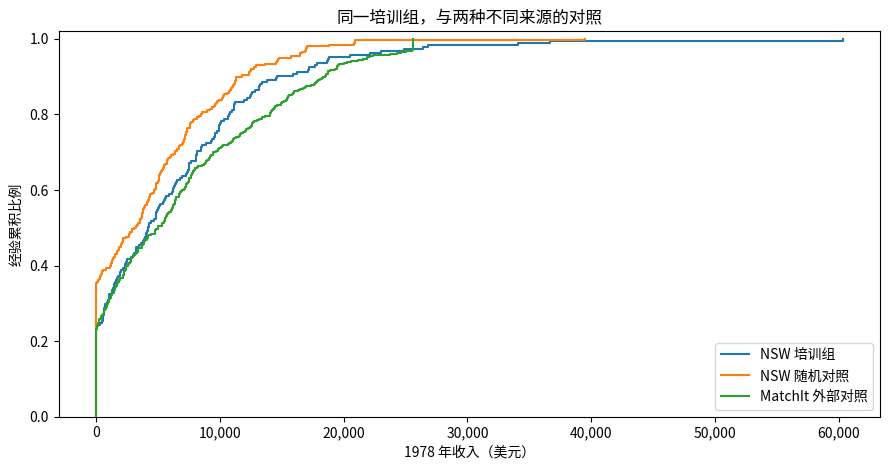

In [4]:
summary = data.groupby("source", sort=False).agg(
    人数=("id", "size"), 平均年龄=("age", "mean"),
    平均1974收入=("re74", "mean"), 平均1975收入=("re75", "mean"),
    平均1978收入=("re78", "mean"), 中位1978收入=("re78", "median"),
    零收入1978比例=("re78", lambda x: x.eq(0).mean()),
)
display(summary.round(2))

fig, ax = plt.subplots(figsize=(9, 4.8))
for frame, label in [(nsw_treated, "NSW 培训组"), (nsw_control, "NSW 随机对照"),
                     (external_control, "MatchIt 外部对照")]:
    values = np.sort(frame.re78.to_numpy(float))
    ax.step(values, np.arange(1, len(values) + 1) / len(values), where="post", label=label)
ax.set(xlabel="1978 年收入（美元）", ylabel="经验累积比例", ylim=(0, 1.02),
       title="同一培训组，与两种不同来源的对照")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

培训组的 1978 年平均收入约为 6,349 美元，随机对照约为 4,555 美元，外部对照约为 6,984 美元。同样的培训组，换一个比较对象，未调整差异就从正变成负。

这还不能说明培训在两个研究中产生了不同作用：处理组根本没有换。改变的是用于代替其未培训结局的那群人。

### 3. 先复现随机试验的三种估计

均值差沿用第二篇。另做两个回归对照：加性回归 `Y ~ T + X`，以及用全体实验样本均值中心化协变量后的交互回归 `Y ~ T * X_centered`。后者的处理系数对应该实验人群的标准化平均比较。三者使用 HC2 稳健标准误，与 Ding 第 15.5.1 节的设置一致。[1，第 4.4、6.2、15.5.1 节]

下面把年龄和收入的数值单位缩小，以免设计矩阵相差太大。变换使用固定常数，不删除变量，不改变线性模型拟合空间。

In [5]:
def make_design(frame, specification="basic"):
    """固定的处理前特征字典；不含处理、来源 ID 或结局。"""
    if specification not in ("basic", "extended"):
        raise ValueError("specification 只能是 basic 或 extended。")
    features = frame[BASE_COVARIATES].astype(float).copy()
    features["age"] = (features["age"] - 25) / 10
    features["educ"] = (features["educ"] - 10) / 5
    features["re74"] /= 10000
    features["re75"] /= 10000
    if specification == "extended":
        for name in ["age", "educ", "re74", "re75"]:
            features[name + "_sq"] = features[name] ** 2
        features["zero74"] = frame.re74.eq(0).astype(float)
        features["zero75"] = frame.re75.eq(0).astype(float)
    features.insert(0, "intercept", 1.0)
    if not np.isfinite(features.to_numpy()).all():
        raise ValueError("特征包含缺失或非有限数值。")
    return features


def mean_difference(frame, outcome="re78"):
    """两组样本均值差，以及 Neyman/Welch 形式的标准误。"""
    t = frame.treat.to_numpy() == 1
    y = frame[outcome].to_numpy(float)
    if min(t.sum(), (~t).sum()) < 2:
        raise ValueError("每组至少需要两人。")
    estimate = y[t].mean() - y[~t].mean()
    se = np.sqrt(y[t].var(ddof=1) / t.sum() + y[~t].var(ddof=1) / (~t).sum())
    return float(estimate), float(se)

T_exp = experimental.treat.to_numpy(float)
Y_exp = experimental.re78.to_numpy(float)
X_exp = make_design(experimental).to_numpy()
X_centered = X_exp[:, 1:] - X_exp[:, 1:].mean(axis=0)
matrices = {
    "均值差": np.column_stack([np.ones(len(experimental)), T_exp]),
    "加性回归": np.column_stack([X_exp, T_exp]),
    "中心化交互回归": np.column_stack([np.ones(len(experimental)), X_centered,
                                  T_exp[:, None] * X_centered, T_exp]),
}
exp_rows = []
for name, matrix in matrices.items():
    result = sm.OLS(Y_exp, matrix).fit(cov_type="HC2")
    estimate, se = result.params[-1], result.bse[-1]
    exp_rows.append([name, estimate, se, estimate - Z_CRIT * se, estimate + Z_CRIT * se])
exp_results = pd.DataFrame(exp_rows, columns=["方法", "估计", "标准误", "下限", "上限"]).set_index("方法")
benchmark, benchmark_se = mean_difference(experimental)
assert np.allclose(exp_results.loc["均值差", ["估计", "标准误"]], [benchmark, benchmark_se])
# 原书给出的精度只有若干小数位，按其显示精度核对。
assert np.allclose(exp_results["估计"], [1794.343, 1676.343, 1621.584], atol=0.001, rtol=0)
assert np.allclose(exp_results["标准误"], [670.9967, 677.0493, 694.7217], atol=0.0001, rtol=0)
display(exp_results.round(2))

,估计,标准误,下限,上限
方法,,,,
均值差,1794.34,671.00,479.21,3109.47
加性回归,1676.34,677.05,349.35,3003.34
中心化交互回归,1621.58,694.72,259.95,2983.21


均值差约为 1,794 美元，标准误约为 671 美元；与书中实验结果相符。协变量调整后的两个点估计有所变化，但不存在一项“训练得到的真值”。后文保留未经协变量调整的均值差作为透明参照。

### 4. 再做一次随机化检验

检验的是尖锐零假设：每个人的培训效应都为零。固定观察结局，按完全随机分配框架保持 185 位处理者，打乱处理标签；统计量用两组均值差除以其 Neyman 标准误。

本篇采用双侧绝对值统计量和 $(1+\text{极端次数})/(B+1)$ 的 Monte Carlo $p$ 值，而书中第 3.4 节先报告了单侧结果。两者定义不同，不要求数值相同。[1，第 3.3–3.4 节、习题 3.3]

观察统计量：2.6741；双侧 Monte Carlo p 值：0.0064


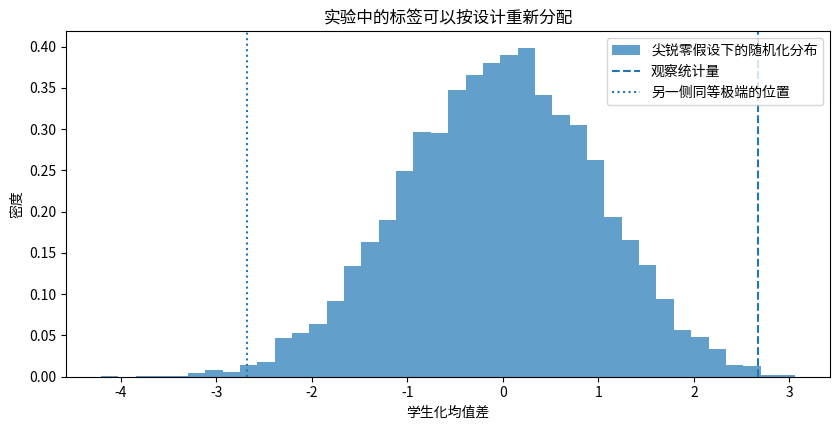

In [6]:
rng_frt = np.random.default_rng(SEED_FRT)
observed_statistic = benchmark / benchmark_se
permuted_statistics = np.empty(N_PERMUTATIONS)
for b in range(N_PERMUTATIONS):
    permuted_t = rng_frt.permutation(T_exp).astype(bool)
    y1, y0 = Y_exp[permuted_t], Y_exp[~permuted_t]
    permuted_statistics[b] = (y1.mean() - y0.mean()) / np.sqrt(
        y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0)
    )
frt_pvalue = (1 + np.sum(np.abs(permuted_statistics) >= abs(observed_statistic))) / (N_PERMUTATIONS + 1)
print(f"观察统计量：{observed_statistic:.4f}；双侧 Monte Carlo p 值：{frt_pvalue:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.hist(permuted_statistics, bins=40, density=True, alpha=0.7, label="尖锐零假设下的随机化分布")
ax.axvline(observed_statistic, linestyle="--", label="观察统计量")
ax.axvline(-abs(observed_statistic), linestyle=":", label="另一侧同等极端的位置")
ax.set(xlabel="学生化均值差", ylabel="密度", title="实验中的标签可以按设计重新分配")
ax.legend()
fig.tight_layout()
plt.show()

这一步的依据是实验的随机分配，不是两组基线检验得到了较大的 $p$ 值。下一部分的外部对照没有经历这次随机分配，所以不能把同一个置换程序直接用于观察性数据。

## 完整案例二：对照换成外部调查后，怎样分析？

### 1. 识别条件与事先列出的模型

对于观察表中的 ATT，已处理者的 $Y(1)$ 可直接观察，缺少的是他们的 $Y(0)$。使用外部对照补足这一项，需要假定，在本篇选择的 $X$ 条件下，外部对照的未培训收入可以代表处理者的反事实未培训收入，并在处理组所在的特征区域中有可比较的对照。仍沿用前面的一致性、处理定义清楚与无个体间干扰要求。这是跨来源的条件可交换性及单侧重叠要求，不是数据合并自动提供的性质。[1，第 13.1 节；2，附录 5.C]

在混合后的分析样本中，$e(X)=P(T=1\mid X)$ 反映成为这份培训组记录、而非成为所选外部对照记录的概率。它会受两种样本的抽取比例影响，不是美国人参加培训的全国概率。

主分析固定使用八个基线变量的 Logistic 评分及对照组线性结果回归。规格检查再加入年龄、教育年数、两年基线收入的二次项，以及两个零收入指示。两种规格都是工作模型；真实数据中不能像第八篇模拟那样将它们标成“正确”和“错误”。扩展规格不根据实验参照挑选，稍后四种组合全部列出。

先只把 `treat` 和基线变量交给评分拟合，并检查两组评分分布。

,人数,最小,中位,最大
T,,,,
0,429,0.0091,0.0758,0.7892
1,185,0.0250,0.6537,0.8532


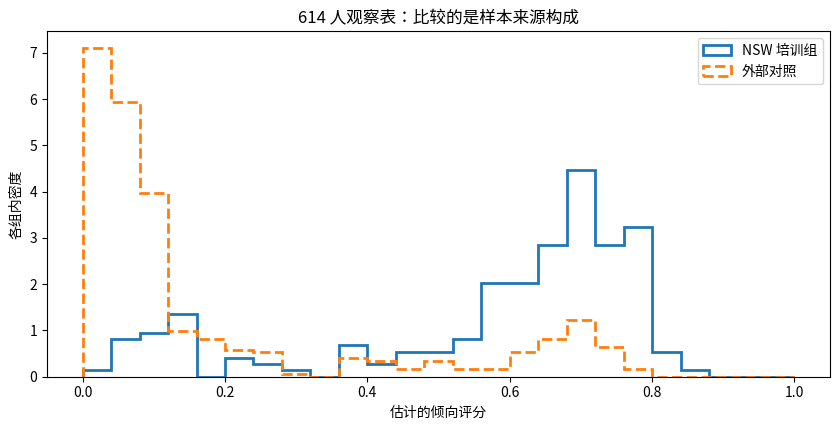

In [7]:
def fit_propensity(frame, specification="basic"):
    t = frame.treat.to_numpy(float)
    if not np.isin(t, [0, 1]).all() or len(np.unique(t)) != 2:
        raise ValueError("处理必须为同时含 0 和 1 的二元变量。")
    x = make_design(frame, specification).to_numpy()
    if np.linalg.matrix_rank(x) < x.shape[1]:
        raise ValueError("评分设计矩阵不满秩。")
    with warnings.catch_warnings():
        warnings.simplefilter("error", PerfectSeparationWarning)
        model = sm.GLM(t, x, family=sm.families.Binomial()).fit(maxiter=100, tol=1e-9)
    if not model.converged:
        raise RuntimeError("倾向评分未收敛。")
    e = np.asarray(model.predict(x))
    if not np.isfinite(e).all() or np.any((e <= 0) | (e >= 1)):
        raise ValueError("倾向评分达到数值边界；本篇不静默截断。")
    return e

T = observational.treat.to_numpy(int)
is_treated = T == 1
n1, n0 = int(is_treated.sum()), int((~is_treated).sum())
design_data = observational[["treat"] + BASE_COVARIATES].copy()
propensity = fit_propensity(design_data)
odds = propensity / (1 - propensity)
logit_score = np.log(odds)
att_weights = np.where(is_treated, 1.0, odds)

score_summary = pd.DataFrame({"T": T, "e": propensity}).groupby("T")["e"].agg(
    人数="size", 最小="min", 中位="median", 最大="max"
)
display(score_summary.round(4))
fig, ax = plt.subplots(figsize=(8.5, 4.4))
bins = np.linspace(0, 1, 26)
ax.hist(propensity[is_treated], bins=bins, density=True, histtype="step", linewidth=2, label="NSW 培训组")
ax.hist(propensity[~is_treated], bins=bins, density=True, histtype="step", linewidth=2, linestyle="--", label="外部对照")
ax.set(xlabel="估计的倾向评分", ylabel="各组内密度", title="614 人观察表：比较的是样本来源构成")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 匹配不读结局，保留配对和复用次数

沿用第七篇的一对一、有放回最近邻匹配：每位处理者在对照中寻找 logit 评分距离最小的人。不设卡钳的主比较保留全部 185 位处理者；它不保证每一对真的足够接近。

出现相同距离时，按对照在数据中的顺序取第一位，使运行可复现。这个并列处理规则与 R Matching 包的默认实现未必相同，所以下面的匹配值不冒充书中 `Match()` 的逐项复现。[1，第 15.2 节；本篇实现规则]

In [8]:
def nearest_pairs(treatment, score, caliper=None):
    """一对一、有放回；输入只有处理和距离分数，不允许结局参与。"""
    t = np.asarray(treatment)
    s = np.asarray(score, dtype=float)
    if t.ndim != 1 or s.shape != t.shape or not np.isfinite(s).all():
        raise ValueError("处理和评分须为等长、有限的一维数组。")
    if not np.isin(t, [0, 1]).all() or len(np.unique(t)) != 2:
        raise ValueError("必须同时有处理组和对照组。")
    if caliper is not None and (not np.isfinite(caliper) or caliper < 0):
        raise ValueError("卡钳须为非负有限数。")
    i1, i0 = np.flatnonzero(t == 1), np.flatnonzero(t == 0)
    distances = np.abs(s[i1, None] - s[i0][None, :])
    nearest = np.argmin(distances, axis=1)
    distance = distances[np.arange(len(i1)), nearest]
    matched = np.ones(len(i1), dtype=bool) if caliper is None else distance <= caliper
    return pd.DataFrame({"treated_index": i1, "control_index": i0[nearest],
                         "distance": distance, "matched": matched})

pairs = nearest_pairs(T, logit_score)
i = pairs.treated_index.to_numpy()
j = pairs.control_index.to_numpy()
match_weights = np.zeros(len(observational))
match_weights[i] = 1
np.add.at(match_weights, j, 1)
assert pairs.matched.all() and len(pairs) == n1
assert match_weights[~is_treated].sum() == n1

pair_preview = pd.DataFrame({
    "培训组ID": observational.id.to_numpy()[i], "对照ID": observational.id.to_numpy()[j],
    "培训组评分": propensity[i], "对照评分": propensity[j], "logit距离": pairs.distance,
    "此对照复用次数": match_weights[j].astype(int),
})
display(pair_preview.head(10).round(4))
print(f"185 位处理者均被保留；使用 {np.unique(j).size} 位不同对照；最大复用 {int(match_weights.max())} 次。")
display(pairs.distance.describe(percentiles=[0.5, 0.9, 0.99]).to_frame("logit 距离").round(4))

,培训组ID,对照ID,培训组评分,对照评分,logit距离,此对照复用次数
0,NSW_T001,PSID69,0.6388,0.6386,0.0009,2
1,NSW_T002,PSID111,0.2246,0.2241,0.0032,1
2,NSW_T003,PSID370,0.6782,0.6788,0.0025,1
3,NSW_T004,PSID226,0.7763,0.7789,0.0150,8
4,NSW_T005,PSID140,0.7016,0.7051,0.0165,5
5,NSW_T006,PSID218,0.6991,0.6935,0.0264,3
6,NSW_T007,PSID256,0.6537,0.6518,0.0085,2
7,NSW_T008,PSID118,0.7897,0.7892,0.0033,9
8,NSW_T009,PSID226,0.7798,0.7789,0.0054,8
9,NSW_T010,PSID344,0.0429,0.0430,0.0021,2


185 位处理者均被保留；使用 80 位不同对照；最大复用 12 次。


,logit 距离
count,185.0000
mean,0.0159
std,0.0392
min,0.0000
50%,0.0064
90%,0.0332
99%,0.1728
max,0.4396


### 3. 加权与匹配，是否把同一群人比较得更接近？

ATT 加权保留处理组权重为 1，对照权重为 $\widehat e(X)/(1-\widehat e(X))$。匹配后的对照权重，则是它被选中的次数。后者不能把重复使用的对照去重后再当作等权样本。[1，第 13.2、15.2、15.4 节]

这里固定用原始 185 位处理者的标准差作为每个变量的标准化分母：

$$
\mathrm{SMD}_j(w)=
\frac{\overline X_{1,w,j}-\overline X_{0,w,j}}{s_{1,j}^{\mathrm{original}}}.
$$

二元变量也使用同一个规则，便于清楚复现；这种 SMD 定义是本篇的诊断约定，不是书中对协变量系数做显著性检验的原图。虚线 0.1 仅为阅读辅助，不是可交换性成立的证明。平方项和零收入也一并检查，不能只看原始变量的均值。

,未调整,ATT 加权,评分匹配
age,-0.309,0.119,0.239
educ,0.055,-0.028,-0.016
black,1.757,-0.006,0.015
hispan,-0.349,0.001,-0.023
married,-0.824,0.047,0.151
nodegree,0.244,0.040,0.012
re74,-0.721,-0.002,-0.049
re75,-0.290,0.011,0.009
age_sq,-0.428,-0.039,0.108
educ_sq,-0.047,-0.081,-0.089


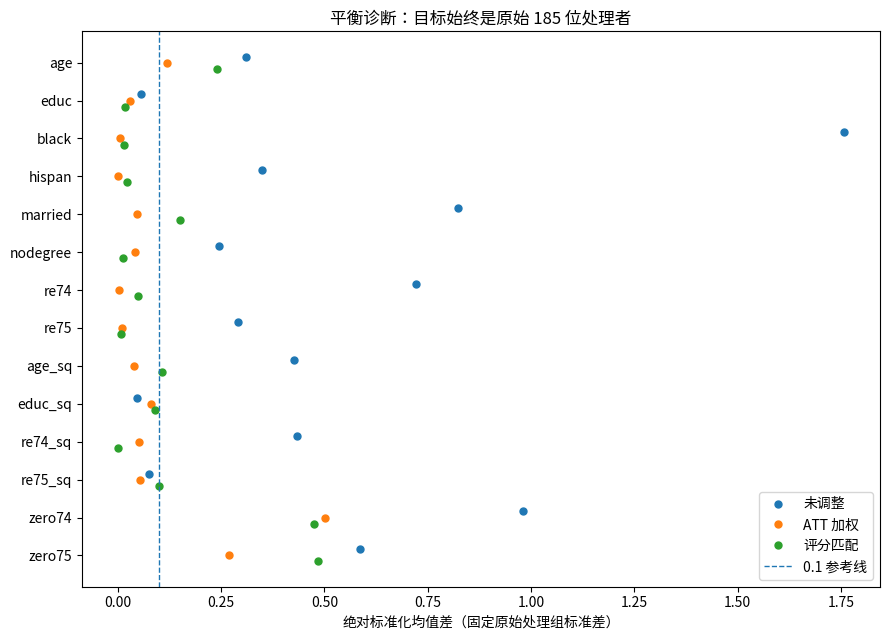

In [9]:
def diagnostic_features(frame):
    d = frame[BASE_COVARIATES].astype(float).copy()
    d["age_sq"] = (frame.age / 10) ** 2
    d["educ_sq"] = (frame.educ / 5) ** 2
    d["re74_sq"] = (frame.re74 / 10000) ** 2
    d["re75_sq"] = (frame.re75 / 10000) ** 2
    d["zero74"] = frame.re74.eq(0).astype(float)
    d["zero75"] = frame.re75.eq(0).astype(float)
    return d


def standardized_difference(features, treatment, weights, denominator):
    x, t, w = np.asarray(features, float), np.asarray(treatment), np.asarray(weights, float)
    den = np.asarray(denominator, float)
    if x.ndim != 2 or len(x) != len(t) or w.shape != t.shape or den.shape != (x.shape[1],):
        raise ValueError("诊断输入维度不一致。")
    if not all(np.isfinite(a).all() for a in (x, w, den)) or np.any(w < 0) or np.any(den <= 0):
        raise ValueError("特征须有限，权重须非负且有限，标准化分母须为正。")
    if not np.isin(t, [0, 1]).all():
        raise ValueError("处理变量须为 0 或 1。")
    masks = (t == 1, t == 0)
    if any(w[mask].sum() <= 0 for mask in masks):
        raise ValueError("每组都须有正的权重总和。")
    means = [np.average(x[mask], axis=0, weights=w[mask]) for mask in masks]
    return (means[0] - means[1]) / den


def effective_n(weights):
    w = np.asarray(weights, float)
    if w.ndim != 1 or not np.isfinite(w).all() or np.any(w < 0) or w.sum() <= 0:
        raise ValueError("有效样本量需要非负、有限且总和为正的权重。")
    return float(w.sum() ** 2 / np.dot(w, w))

balance_x = diagnostic_features(observational)
smd_denominator = balance_x.loc[is_treated].std(ddof=1).to_numpy()
weight_schemes = {"未调整": np.ones(len(T)), "ATT 加权": att_weights, "评分匹配": match_weights}
balance = pd.DataFrame({name: standardized_difference(balance_x, T, w, smd_denominator)
                        for name, w in weight_schemes.items()}, index=balance_x.columns)
display(balance.round(3))

fig, ax = plt.subplots(figsize=(9, 6.5))
positions = np.arange(len(balance))
for offset, (name, values) in zip([-0.16, 0, 0.16], balance.items()):
    ax.plot(values.abs(), positions + offset, "o", label=name, markersize=5)
ax.axvline(0.1, linestyle="--", linewidth=1, label="0.1 参考线")
ax.set_yticks(positions, balance.index)
ax.invert_yaxis()
ax.set(xlabel="绝对标准化均值差（固定原始处理组标准差）", title="平衡诊断：目标始终是原始 185 位处理者")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

### 4. 不只看 SMD，还要看数据由多少人支撑

有效样本量（ESS）用 $(\sum w)^2/\sum w^2$ 描述权重是否集中。它不是严格等价的独立观测数，也不是处理效应标准误公式。匹配保留了 185 对，并不等于找到了 185 位不同的对照。

下表同时列出对照人数、ESS、最大权重占比与收入前的平衡指标。再用 1975 年收入的加权经验分布检查一个重要基线变量；这个图不看 1978 年结局。

,不同对照数,对照ESS,最大权重占比,前5权重占比,最大绝对SMD
方法,,,,,
未调整,429,429.000,0.002,0.012,1.757
ATT 加权,429,99.815,0.020,0.089,0.501
评分匹配,80,43.488,0.065,0.238,0.484


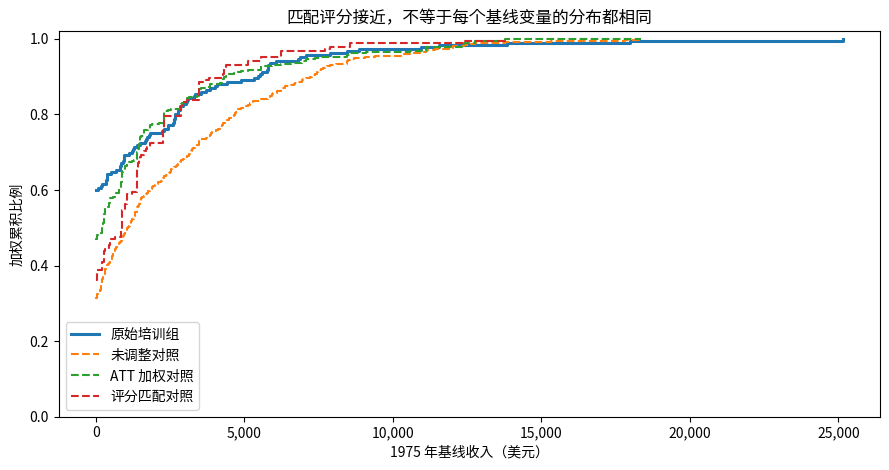

In [10]:
design_rows = []
for name, weights in weight_schemes.items():
    wc = weights[~is_treated]
    design_rows.append([name, int((wc > 0).sum()), effective_n(wc),
                        wc.max() / wc.sum(), np.sort(wc)[-5:].sum() / wc.sum(),
                        balance[name].abs().max()])
design_diagnostics = pd.DataFrame(design_rows, columns=[
    "方法", "不同对照数", "对照ESS", "最大权重占比", "前5权重占比", "最大绝对SMD"
]).set_index("方法")
display(design_diagnostics.round(3))


def weighted_ecdf(values, weights):
    v, w = np.asarray(values, float), np.asarray(weights, float)
    if v.shape != w.shape or not np.isfinite(v).all() or not np.isfinite(w).all():
        raise ValueError("值与权重须同形且有限。")
    if np.any(w < 0) or w.sum() <= 0:
        raise ValueError("权重须非负且总和为正。")
    keep = w > 0
    unique_values, inverse = np.unique(v[keep], return_inverse=True)
    masses = np.bincount(inverse, weights=w[keep])
    return unique_values, np.cumsum(masses) / masses.sum()

fig, ax = plt.subplots(figsize=(9, 4.8))
x, cdf = weighted_ecdf(observational.re75.to_numpy()[is_treated], np.ones(n1))
ax.step(x, cdf, where="post", linewidth=2.2, label="原始培训组")
for name, weights in weight_schemes.items():
    x, cdf = weighted_ecdf(observational.re75.to_numpy()[~is_treated], weights[~is_treated])
    ax.step(x, cdf, where="post", linestyle="--", label=name + "对照")
ax.set(xlabel="1975 年基线收入（美元）", ylabel="加权累积比例", ylim=(0, 1.02),
       title="匹配评分接近，不等于每个基线变量的分布都相同")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

主规格的对照加权 ESS 约为 100，低于原来的 429 人；评分匹配只使用 80 位不同对照，其中一位被复用 12 次。两年收入的加权均值已经很接近，但 `zero74`、`zero75` 的绝对 SMD 仍约为 0.501、0.270；匹配后的两个值也接近 0.5。平均收入相近，掩盖了“有多少人收入为零”的差别。

这套基本规格并没有把重要的基线分布调整充分。下面继续计算，是为了看清各个估计如何形成，并与已声明的扩展规格比较；不是把这些权重或配对直接当作已经通过诊断的最终设计。

## 把 ATT 公式用到同一张观察表

### 1. 先写清楚每种方法在补哪一项

记 $\widehat m_0(X)$ 为用外部对照拟合的未培训收入，$\widehat o_i=\widehat e_i/(1-\widehat e_i)$。以下几种方法都先保留实际处理组平均收入，再估计其反事实未培训均值：[1，第 13.1–13.2 节]

$$
\begin{aligned}
\widehat\tau_T^{\mathrm{reg}}
&=\frac1{n_1}\sum_{T_i=1}\{Y_i-\widehat m_0(X_i)\},\\
\widehat\tau_T^{\mathrm{HT}}
&=\overline Y_1-\frac1{n_1}\sum_{T_i=0}\widehat o_iY_i,\\
\widehat\tau_T^{\mathrm{Hajek}}
&=\overline Y_1-\frac{\sum_{T_i=0}\widehat o_iY_i}{\sum_{T_i=0}\widehat o_i},\\
\widehat\tau_T^{\mathrm{DR}}
&=\widehat\tau_T^{\mathrm{reg}}
-\frac1{n_1}\sum_{T_i=0}\widehat o_i\{Y_i-\widehat m_0(X_i)\}.
\end{aligned}
$$

最后一式是 ATT 的 AIPW，不是把第八篇的全体 ATE 得分拿来只平均处理组。它只需要一个对照结果模型；实际处理组的 $Y(1)$ 已经观察到了。这里采用 Ding 定义 13.1 与第 13.3 节 R 函数中的符号，不使用该章后面排版有误的等价重写。

匹配也使用同一个目标。最近邻为 $j(i)$ 时，未校正估计为 $n_1^{-1}\sum_{T_i=1}(Y_i-Y_{j(i)})$；偏差校正则从每一对差中减去 $\widehat m_0(X_i)-\widehat m_0(X_{j(i)})$。[1，第 15.4 节]

In [11]:
def fit_control_outcome(frame, specification="basic", outcome="re78"):
    x = make_design(frame, specification).to_numpy()
    control = frame.treat.to_numpy() == 0
    y = frame[outcome].to_numpy(float)
    if not np.isfinite(y).all() or control.sum() <= x.shape[1]:
        raise ValueError("结局须有限，且对照数须大于结果模型参数数。")
    beta, _, rank, _ = np.linalg.lstsq(x[control], y[control], rcond=None)
    if rank < x.shape[1]:
        raise ValueError("对照结果模型不满秩。")
    return x @ beta


def att_from_predictions(treatment, outcome, e, m0):
    """只做公式计算；输出估计值及反事实均值，不隐藏重新归一化。"""
    t, y, e, m = [np.asarray(a) for a in (treatment, outcome, e, m0)]
    if t.ndim != 1 or not (t.shape == y.shape == e.shape == m.shape):
        raise ValueError("输入须是同形的一维数组。")
    if not np.isin(t, [0, 1]).all() or len(np.unique(t)) != 2:
        raise ValueError("必须有两组。")
    if not all(np.isfinite(a).all() for a in (y, e, m)) or np.any((e <= 0) | (e >= 1)):
        raise ValueError("预测须有限，且评分严格位于 (0, 1)。")
    treated, control = t == 1, t == 0
    n_treated = treated.sum()
    odds_c = e[control] / (1 - e[control])
    factual_mean = y[treated].mean()
    reg_m0 = m[treated].mean()
    ht_m0 = np.dot(odds_c, y[control]) / n_treated
    hajek_m0 = np.average(y[control], weights=odds_c)
    residual_correction = np.dot(odds_c, y[control] - m[control]) / n_treated
    counterfactual = pd.Series({"回归标准化": reg_m0, "ATT-HT": ht_m0,
                               "ATT-Hajek": hajek_m0, "ATT-AIPW": reg_m0 + residual_correction})
    effects = factual_mean - counterfactual
    return effects, counterfactual, float(residual_correction)

Y = observational.re78.to_numpy(float)
m0 = fit_control_outcome(observational)
main_effects, counterfactual_means, correction = att_from_predictions(T, Y, propensity, m0)
matching_effect = np.mean(Y[i] - Y[j])
matching_bc_effect = np.mean(Y[i] - Y[j] - m0[i] + m0[j])
raw_observational, raw_observational_se = mean_difference(observational)

point_results = pd.DataFrame({
    "处理组实际平均收入": Y[is_treated].mean(),
    "反事实未培训均值": counterfactual_means,
    "ATT估计": main_effects,
})
display(point_results.round(2))
display(pd.Series({"未调整均值差（非ATT保证）": raw_observational,
                   "评分匹配": matching_effect, "匹配+结果校正": matching_bc_effect}, name="点估计").round(2).to_frame())
print(f"AIPW = 回归 {main_effects['回归标准化']:.2f} - 对照残差修正 {correction:.2f}")
print("处理组的线性未培训均值预测为负的记录数：", int(np.sum(m0[is_treated] < 0)))
# 复用次数加权与逐对求差应给出相同结果。
assert np.isclose(matching_effect, Y[is_treated].mean() - np.average(Y[~is_treated], weights=match_weights[~is_treated]))
assert np.isclose(main_effects["ATT-AIPW"], np.mean(Y[is_treated] - m0[is_treated]) - correction)

,处理组实际平均收入,反事实未培训均值,ATT估计
回归标准化,6349.15,4701.56,1647.58
ATT-HT,6349.15,5190.56,1158.59
ATT-Hajek,6349.15,5135.07,1214.07
ATT-AIPW,6349.15,5122.60,1226.55


,点估计
未调整均值差（非ATT保证）,-635.02
评分匹配,1967.94
匹配+结果校正,2103.84


AIPW = 回归 1647.58 - 对照残差修正 421.04
处理组的线性未培训均值预测为负的记录数： 0


主规格下，回归标准化约为 1,648 美元，Hájek 加权约为 1,214 美元，AIPW 约为 1,227 美元。AIPW 没有把两个答案取平均：它从回归估计中减去了约 421 美元的对照加权残差。

评分匹配与偏差校正后的匹配也给出正值，但使用的对照更少。几种正值不能相互投票证明识别条件成立；它们共用相同处理组、协变量和同一外部资料。线性模型也不强制非负预测，本篇不在拟合后悄悄截为零，因为那会换成另一种估计。

### 2. 给平滑估计做完整重拟合 Bootstrap

这一部分为结果回归、两种加权与 AIPW 计算误差，不给固定最近邻匹配套普通 Bootstrap 或独立配对标准误。[1，第 13.2 节；第 15.3.1 节]

为保留两张分析表共用处理组的关系，每次分别在三个来源内有放回抽样：185 位 NSW 处理者只抽一次，同时供实验表与观察表使用；260 位随机对照与 429 位外部对照分别抽样。然后重新拟合评分和对照结果模型。这样还能计算“观察性估计减实验参照”的分布，不错误地把两个标准误平方相加。

这是本篇的三来源条件抽样实现，保持各来源样本数固定；书中 ATT 示例使用的是混合表整行重抽样。这里的区间采用三个来源可按独立样本重抽的工作框架，描述固定规格下的抽样不确定性，不是原随机化设计的精确区间，更不涵盖未测混杂、样本来源不相容或模型搜索的不确定性。实验主结果仍使用前面的 Neyman 区间。

In [12]:
def fit_smooth_att(frame, ps_spec="basic", outcome_spec="basic", outcome="re78"):
    e = fit_propensity(frame, ps_spec)
    m = fit_control_outcome(frame, outcome_spec, outcome=outcome)
    estimates, counterfactual, _ = att_from_predictions(
        frame.treat.to_numpy(), frame[outcome].to_numpy(float), e, m
    )
    return estimates, counterfactual


rng_boot = np.random.default_rng(SEED_BOOT)
bootstrap_rows, bootstrap_failures = [], []
for b in range(N_BOOT):
    bt = nsw_treated.iloc[rng_boot.integers(0, len(nsw_treated), len(nsw_treated))]
    bc = nsw_control.iloc[rng_boot.integers(0, len(nsw_control), len(nsw_control))]
    be = external_control.iloc[rng_boot.integers(0, len(external_control), len(external_control))]
    boot_observational = pd.concat([bt, be], ignore_index=True)
    try:
        effects_b, means_b = fit_smooth_att(boot_observational)
        row = effects_b.to_dict()
        row["实验均值差"] = bt.re78.mean() - bc.re78.mean()
        row["未调整均值差"] = bt.re78.mean() - be.re78.mean()
        row["处理组均值"] = bt.re78.mean()
        row["AIPW反事实均值"] = means_b["ATT-AIPW"]
        bootstrap_rows.append(row)
    except (ValueError, RuntimeError, np.linalg.LinAlgError, PerfectSeparationWarning) as error:
        bootstrap_failures.append((b, str(error)))

print(f"Bootstrap 成功 {len(bootstrap_rows)}/{N_BOOT} 次，失败 {len(bootstrap_failures)} 次。")
if bootstrap_failures:
    display(pd.DataFrame(bootstrap_failures, columns=["重复编号", "原因"]).head())
    raise RuntimeError("存在失败拟合，停止计算区间；不把失败重复静默排除。")
boot = pd.DataFrame(bootstrap_rows)
smooth_intervals = pd.DataFrame({"估计": main_effects, "Bootstrap标准误": boot[main_effects.index].std(ddof=1)})
smooth_intervals["下限"] = smooth_intervals["估计"] - Z_CRIT * smooth_intervals["Bootstrap标准误"]
smooth_intervals["上限"] = smooth_intervals["估计"] + Z_CRIT * smooth_intervals["Bootstrap标准误"]
display(smooth_intervals.round(2))

# 两张表不是独立研究：比较差值时沿用同一次处理组重抽样。
paired_gap = boot["ATT-AIPW"] - boot["实验均值差"]
comparison_gap = main_effects["ATT-AIPW"] - benchmark
print(f"AIPW 减实验参照：{comparison_gap:.2f}；联合 Bootstrap 标准误：{paired_gap.std(ddof=1):.2f}")
print(f"错误地忽略协方差所得标准误：{np.hypot(boot['ATT-AIPW'].std(ddof=1), boot['实验均值差'].std(ddof=1)):.2f}")

Bootstrap 成功 999/999 次，失败 0 次。


,估计,Bootstrap标准误,下限,上限
回归标准化,1647.58,831.64,17.59,3277.58
ATT-HT,1158.59,841.03,-489.79,2806.97
ATT-Hajek,1214.07,829.28,-411.29,2839.43
ATT-AIPW,1226.55,830.98,-402.15,2855.24


AIPW 减实验参照：-567.80；联合 Bootstrap 标准误：665.98
错误地忽略协方差所得标准误：1060.74


### 3. 把估计和误差范围放在同一张图上

背景带是实验均值差的 95% Neyman 区间，仅作参照。观察性方法的误差线来自刚才固定主规格的 Bootstrap。匹配两项只画点，明确表示本篇没有为它们实现合适的完整标准误，而不是标准误为零。

默认结果中，回归标准化的区间下限仅约 18 美元；两种加权与 AIPW 的区间均包含零。不能在这些方法中挑出唯一“显著”的结果，就把它作为培训有效的稳健结论。

点估计接近、区间重叠或差值区间包含零，都不能证明两种设计等价；这里还涉及不同的目标解释、共享记录和较大的抽样误差。

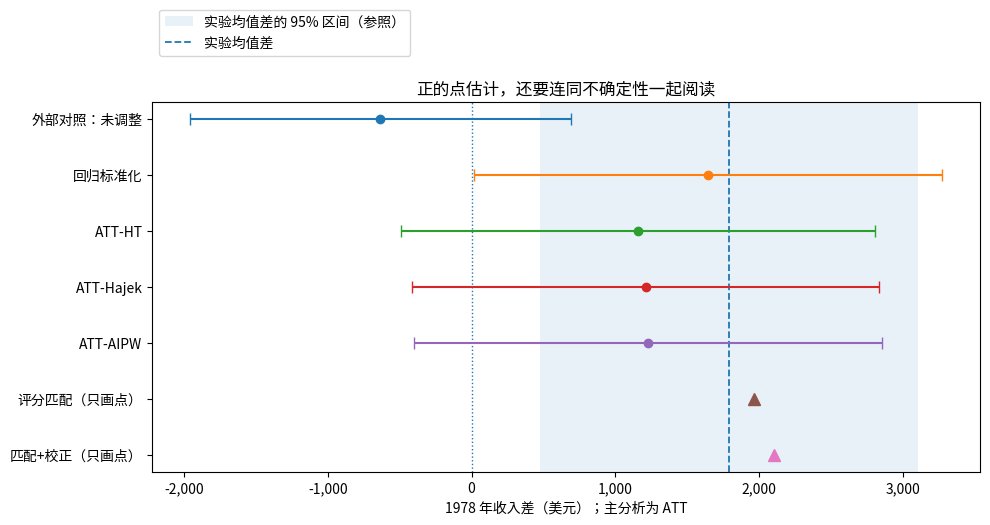

In [13]:
plot_rows = []
raw_se_boot = boot["未调整均值差"].std(ddof=1)
plot_rows.append(["外部对照：未调整", raw_observational, raw_se_boot])
for name in main_effects.index:
    plot_rows.append([name, main_effects[name], smooth_intervals.loc[name, "Bootstrap标准误"]])
plot_rows += [["评分匹配（只画点）", matching_effect, np.nan],
              ["匹配+校正（只画点）", matching_bc_effect, np.nan]]
plot_table = pd.DataFrame(plot_rows, columns=["方法", "估计", "标准误"])

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(benchmark - Z_CRIT * benchmark_se, benchmark + Z_CRIT * benchmark_se,
           alpha=0.10, label="实验均值差的 95% 区间（参照）")
ax.axvline(benchmark, linestyle="--", linewidth=1.3, label="实验均值差")
ax.axvline(0, linestyle=":", linewidth=1)
for k, row in plot_table.iterrows():
    if np.isfinite(row["标准误"]):
        ax.errorbar(row["估计"], k, xerr=Z_CRIT * row["标准误"], fmt="o", capsize=4)
    else:
        ax.plot(row["估计"], k, marker="^", markersize=8)
ax.set_yticks(np.arange(len(plot_table)), plot_table["方法"])
ax.invert_yaxis()
ax.set(xlabel="1978 年收入差（美元）；主分析为 ATT", title="正的点估计，还要连同不确定性一起阅读")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.27), fontsize=10)
fig.tight_layout()
plt.show()

## 检查结果依赖于哪些选择

### 1. 扩展模型规格，不将“更复杂”写成“更正确”

评分基本型与扩展型、结果基本型与扩展型组合成四种设定。均使用全部 614 人、同一个 ATT 目标；没有依照结局或实验值筛掉任何一种。

表中另外报告各评分规格的对照 ESS、最大绝对 SMD 和权重集中程度。单纯加入二次项，未必让用于效应估计的权重更稳定。扩展规格若产生较大变化，需要报告并解释，不将其中最接近 1,794 的一项选为“最终模型”。

回归标准化   ATT-HT  ATT-Hajek  ATT-AIPW
评分规格     结果规格                                           
basic    basic     1647.58  1158.59    1214.07   1226.55
         extended  1262.30  1158.59    1214.07    937.78
extended basic     1647.58   663.80    1378.43    816.37
         extended  1262.30   663.80    1378.43    902.11

,对照ESS,最大绝对SMD,最大权重占比,最大评分
评分,,,,
basic,99.815,0.501,0.020,0.853
extended,24.911,0.177,0.112,0.979


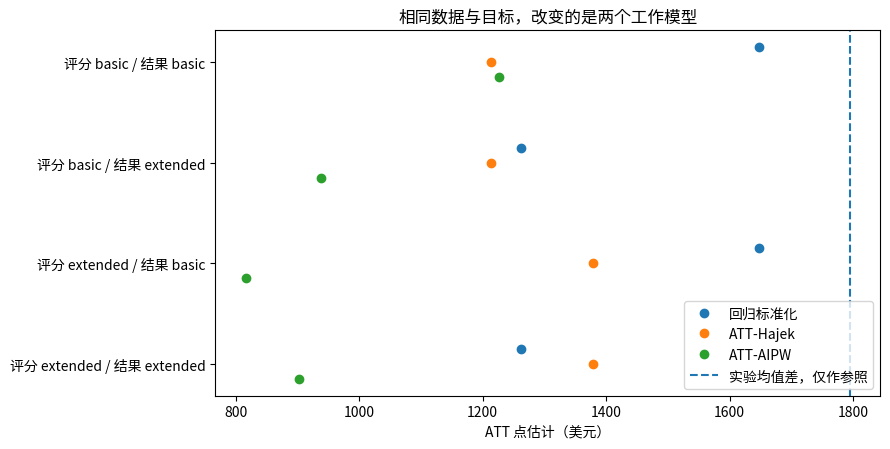

In [14]:
spec_rows, spec_diagnostics = [], []
for ps_spec in ["basic", "extended"]:
    e_spec = fit_propensity(observational, ps_spec)
    w_spec = np.where(is_treated, 1.0, e_spec / (1 - e_spec))
    smd_spec = standardized_difference(balance_x, T, w_spec, smd_denominator)
    wc = w_spec[~is_treated]
    spec_diagnostics.append([ps_spec, effective_n(wc), np.max(np.abs(smd_spec)),
                             wc.max() / wc.sum(), e_spec.max()])
    for outcome_spec in ["basic", "extended"]:
        m_spec = fit_control_outcome(observational, outcome_spec)
        effects_spec, _, _ = att_from_predictions(T, Y, e_spec, m_spec)
        spec_rows.append({"评分规格": ps_spec, "结果规格": outcome_spec, **effects_spec.to_dict()})
spec_results = pd.DataFrame(spec_rows).set_index(["评分规格", "结果规格"])
display(spec_results.round(2))
display(pd.DataFrame(spec_diagnostics, columns=["评分", "对照ESS", "最大绝对SMD", "最大权重占比", "最大评分"]).set_index("评分").round(3))

fig, ax = plt.subplots(figsize=(9, 4.6))
labels = [f"评分 {a} / 结果 {b}" for a, b in spec_results.index]
for offset, name in zip([-0.15, 0, 0.15], ["回归标准化", "ATT-Hajek", "ATT-AIPW"]):
    ax.plot(spec_results[name], np.arange(4) + offset, "o", label=name)
ax.axvline(benchmark, linestyle="--", label="实验均值差，仅作参照")
ax.set_yticks(np.arange(4), labels)
ax.invert_yaxis()
ax.set(xlabel="ATT 点估计（美元）", title="相同数据与目标，改变的是两个工作模型")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

扩展评分把最大绝对 SMD 从约 0.501 降到约 0.177，平衡有所改善；同时，对照 ESS 从约 100 降到约 25，最大单个权重占比从约 2% 升到约 11.2%。改善平衡和集中权重同时发生，不能只挑一个指标评价。

四种 AIPW 结果约在 816–1,227 美元之间。它们不是第八篇已知生成机制下的“四象限实验”，无法从这张表判断哪一边拟合正确。

如果某个模型的预测拟合更好，但少数对照承担了很大权重，仍要检查影响大的记录及它们所支持的人群。这里不把实际观察到的波动改写成“复杂模型更稳健”。

### 2. 卡钳更窄，保留的还是原来那群人吗？

固定主评分，不重拟合；逐渐缩小允许的 logit 距离。下面记录处理者保留数、不同对照数及保留者的基线特征，再计算匹配结果。卡钳按全体观察表 logit 评分标准差的倍数定义，是本篇的演示选择，不是针对这份数据优化出的通用阈值。

一旦剔除了处理者，表中的估计只能作为保留处理者的平均效应估计来解释；这个保留集合由实际样本和匹配规则产生，不能直接等同于一个事先固定的总体子群。我们不知道被排除者的个体效应，也不能像第六篇模拟那样算出目标变化的真值。[1，第 15.2 节]

,保留处理者,排除处理者,不同对照,保留者平均年龄,保留者基线1975收入,匹配估计,匹配校正估计
卡钳倍数,,,,,,,
0.005,104,81,66,25.17,1376.95,2243.39,2591.75
0.01,142,43,76,25.28,1265.81,1961.14,2250.00
0.025,178,7,80,25.54,1473.41,2091.73,2232.77
0.05,180,5,80,25.52,1492.73,2012.56,2141.90
0.1,183,2,80,25.68,1505.81,2015.19,2150.16
0.2,184,1,80,25.78,1497.62,1974.37,2117.68
不限制,185,0,80,25.82,1532.06,1967.94,2103.84


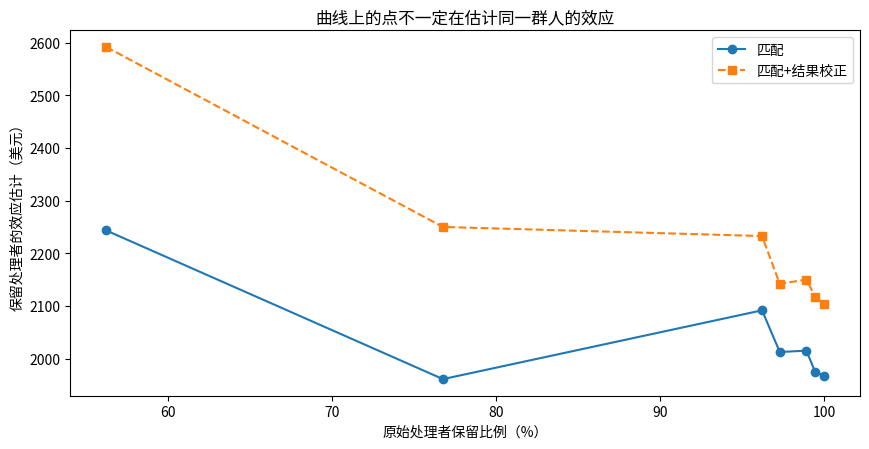

In [15]:
caliper_rows = []
logit_sd = logit_score.std(ddof=1)
for multiplier in (*CALIPER_MULTIPLIERS, None):
    selected = nearest_pairs(T, logit_score, None if multiplier is None else multiplier * logit_sd)
    retained = selected.loc[selected.matched]
    ii, jj = retained.treated_index.to_numpy(), retained.control_index.to_numpy()
    if len(ii) == 0:
        raise RuntimeError("本配置没有匹配成功的处理者，不能计算效应。")
    caliper_rows.append({
        "卡钳倍数": "不限制" if multiplier is None else str(multiplier),
        "保留处理者": len(ii), "排除处理者": n1 - len(ii), "不同对照": len(np.unique(jj)),
        "保留者平均年龄": observational.age.to_numpy()[ii].mean(),
        "保留者基线1975收入": observational.re75.to_numpy()[ii].mean(),
        "匹配估计": np.mean(Y[ii] - Y[jj]),
        "匹配校正估计": np.mean(Y[ii] - Y[jj] - m0[ii] + m0[jj]),
    })
caliper_results = pd.DataFrame(caliper_rows).set_index("卡钳倍数")
display(caliper_results.round(2))

fig, ax = plt.subplots(figsize=(8.8, 4.6))
retention = 100 * caliper_results["保留处理者"] / n1
ax.plot(retention, caliper_results["匹配估计"], "o-", label="匹配")
ax.plot(retention, caliper_results["匹配校正估计"], "s--", label="匹配+结果校正")
ax.set(xlabel="原始处理者保留比例（%）", ylabel="保留处理者的效应估计（美元）",
       title="曲线上的点不一定在估计同一群人的效应")
ax.legend()
fig.tight_layout()
plt.show()

### 3. 固定模型，再改变对未测混杂的假定

沿用上一份笔记的比值思路，但这次目标是 ATT，只需要 $\varepsilon_0$。暂时设为正的常数：

$$
\kappa=
\frac{E[Y(0)\mid T=1,X=x]}{E[Y(0)\mid T=0,X=x]}.
$$

$\kappa=1$ 是未培训条件均值可交换的基准；$\kappa>1$ 表示同样的已记录基线下，处理者即使不培训，本来也有较高的平均收入。按 Ding 第 18.4 节，在给定这个常数假设时：

$$
\widehat\tau_T(\kappa)
=\overline Y_1-\kappa\widehat M_{0T}^{\mathrm{DR}}.
$$

这里 $\widehat M_{0T}^{\mathrm{DR}}$ 就是前面 AIPW 对反事实未培训均值的基准估计。常数 $\kappa$ 同时乘预测项与加权残差项，而不是只改某个人的收入。

范围 0.7–1.6 只是演示，不是从数据推得的可信区间。比值设定要求相关条件均值适合用正值比率描述；线性工作模型本身不保证处处为正，这也是此项分析的限制。下图仍只是该工作模型下的敏感性计算。[1，第 18.4 节；本篇参数范围]

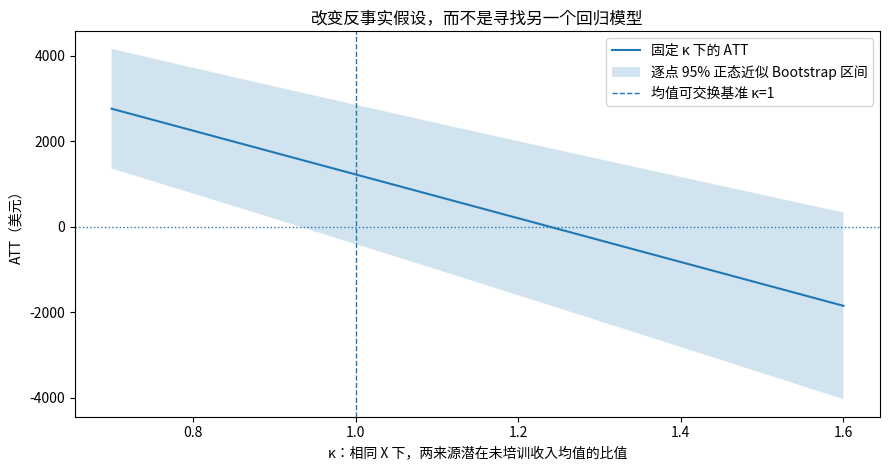

使本次点估计归零的 κ：1.239
κ=1 的区间： (-402.15, 2855.24)


In [16]:
kappa_grid = np.linspace(0.7, 1.6, 91)
factual_mean = Y[is_treated].mean()
m0_att_dr = counterfactual_means["ATT-AIPW"]
sensitivity_estimate = factual_mean - kappa_grid * m0_att_dr
boot_sensitivity = (boot["处理组均值"].to_numpy()[:, None]
                    - boot["AIPW反事实均值"].to_numpy()[:, None] * kappa_grid[None, :])
sensitivity_se = boot_sensitivity.std(axis=0, ddof=1)
sensitivity_lower = sensitivity_estimate - Z_CRIT * sensitivity_se
sensitivity_upper = sensitivity_estimate + Z_CRIT * sensitivity_se
assert np.isclose(factual_mean - m0_att_dr, main_effects["ATT-AIPW"])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(kappa_grid, sensitivity_estimate, label="固定 κ 下的 ATT")
ax.fill_between(kappa_grid, sensitivity_lower, sensitivity_upper, alpha=0.2,
                label="逐点 95% 正态近似 Bootstrap 区间")
ax.axhline(0, linestyle=":", linewidth=1)
ax.axvline(1, linestyle="--", linewidth=1, label="均值可交换基准 κ=1")
ax.set(xlabel="κ：相同 X 下，两来源潜在未培训收入均值的比值", ylabel="ATT（美元）",
       title="改变反事实假设，而不是寻找另一个回归模型")
ax.legend()
fig.tight_layout()
plt.show()
if m0_att_dr > 0:
    print(f"使本次点估计归零的 κ：{factual_mean / m0_att_dr:.3f}")
else:
    print("反事实均值不为正，不能使用正均值比值解释归零点。")
print("κ=1 的区间：", tuple(np.round(smooth_intervals.loc["ATT-AIPW", ["下限", "上限"]], 2)))

本次点估计在 $\kappa\approx1.239$ 时归零；但 $\kappa=1$ 的 AIPW 区间约为 [−402, 2,855] 美元，本来就包含零。因此，不能将 1.239 描述成“还需要这么强的混杂才会失去显著性”。“点估计归零”与“置信区间开始包含零”是两个问题；这条曲线也没有检验出真实的 $\kappa$。

曲线的每个区间，都以该处假设为固定条件；将整个阴影称为“未测混杂的不确定性范围”是不准确的。它也不是覆盖整条曲线的同时置信带。

## 练习

### 1. 只改平均人群，ATE 与 ATT 会怎样不同？

现在额外拟合处理组的结果模型 $\widehat m_1(X)$。一组预测在全体 614 人上平均，另一组只在 185 位处理者上平均：

$$
\widehat\tau_{\mathrm{ATE,reg}}=\frac1n\sum_i\{\widehat m_1(X_i)-\widehat m_0(X_i)\},
\qquad
\widehat\tau_{\mathrm{ATT,reg}}=\frac1{n_1}\sum_{T_i=1}\{\widehat m_1(X_i)-\widehat m_0(X_i)\}.
$$

这个全体 ATE 指向的是拼接资料代表的混合人群，不自动代表美国总体或原始 NSW 人群。用处理组信息去预测大量外部对照的培训结局还需要另一方向的重叠与可交换性；因此这里只把它作为目标改变的计算练习，不另立为主结论。[1，第 10.4、13.1 节]

In [17]:
X_all = make_design(observational).to_numpy()
beta1 = np.linalg.lstsq(X_all[is_treated], Y[is_treated], rcond=None)[0]
m1 = X_all @ beta1
predicted_effect = m1 - m0
ate_regression = predicted_effect.mean()
att_regression_two_models = predicted_effect[is_treated].mean()
# 处理组含截距的 OLS，使其组内平均拟合值等于实际组内均值。
assert np.isclose(att_regression_two_models, main_effects["回归标准化"])

# 交互模型把协变量中心化在处理组均值，处理系数应是同一个 ATT。
X_c_treated = X_all[:, 1:] - X_all[is_treated, 1:].mean(axis=0)
interaction_design = np.column_stack([np.ones(len(T)), X_c_treated,
                                      T[:, None] * X_c_treated, T])
interaction_att = np.linalg.lstsq(interaction_design, Y, rcond=None)[0][-1]
assert np.isclose(interaction_att, att_regression_two_models)
display(pd.Series({
    "全部614人平均：混合人群ATE": ate_regression,
    "仅185位处理者平均：ATT": att_regression_two_models,
    "处理组均值中心化的交互系数": interaction_att,
}, name="结果回归估计（美元）").round(2).to_frame())

,结果回归估计（美元）
全部614人平均：混合人群ATE,1074.91
仅185位处理者平均：ATT,1647.58
处理组均值中心化的交互系数,1647.58


后两项相等是带截距 OLS 与完整交互模型的代数性质，不是模型已经通过因果验证。第一项不同，也不必解释成某个算法算错：平均人群已经换了，而且对处理组范围之外作了更多预测。

### 2. 将结局改为“是否有正收入”，还能直接读收入差吗？

令 $Y^+=1(Y>0)$。这次目标是处理者的正收入概率差，单位为百分点，不再是美元。使用对照组 Logistic 回归拟合 $P(Y^+=1\mid T=0,X)$，然后代入同一个 ATT 公式。[1，第 10.4.2、13.3 节]

这里“有正收入”只来自记录定义，不擅自把它改叫就业率。也不要从 Logistic 系数直接读概率差，或把一个美元效应除以平均收入当成这个新目标。

In [18]:
y_positive = (Y > 0).astype(float)
with warnings.catch_warnings():
    warnings.simplefilter("error", PerfectSeparationWarning)
    binary_model = sm.GLM(y_positive[~is_treated], X_all[~is_treated],
                          family=sm.families.Binomial()).fit(maxiter=100, tol=1e-9)
if not binary_model.converged:
    raise RuntimeError("二元结局模型未收敛。")
m0_positive = np.asarray(binary_model.predict(X_all))
positive_effects, positive_cf, _ = att_from_predictions(T, y_positive, propensity, m0_positive)
positive_raw = y_positive[is_treated].mean() - y_positive[~is_treated].mean()
positive_experimental = (experimental.loc[experimental.treat.eq(1), "re78"] > 0).mean() - (
    experimental.loc[experimental.treat.eq(0), "re78"] > 0).mean()
positive_results = pd.concat([
    pd.Series({"实验均值差（参照）": positive_experimental, "外部对照未调整差": positive_raw}),
    positive_effects,
])
display((100 * positive_results).round(2).to_frame("正收入概率差（百分点）"))
print("本练习只报告点估计；收入效应的 Bootstrap 区间不能直接拿来套用。")

,正收入概率差（百分点）
实验均值差（参照）,11.06
外部对照未调整差,-1.48
回归标准化,5.12
ATT-HT,0.45
ATT-Hajek,1.26
ATT-AIPW,2.22


本练习只报告点估计；收入效应的 Bootstrap 区间不能直接拿来套用。


概率结局的回归、加权和 AIPW 仍然在回答同一个 ATT 问题，但不会等于刚才的美元差。结果模型的预测位于 0 到 1 之间，也不意味着 HT 或 AIPW 的有限样本组合一定落在概率差的参数范围内；本篇未对结果作事后裁切。

## 总结

这份分析先复现了实验均值差约 1,794 美元及其标准误，再用同一份处理组与另一来源的对照重做比较。外部对照的未调整差约为 −635 美元；基本规格的回归、加权与 AIPW 调整后变为正值，匹配结果也为正。解释这些变化时，不能跳过基线构成、对照复用与权重集中程度。

实际报告还应同时保留几项信息：主分析针对全部 185 位处理者的 ATT；主规格仍有零收入分布不平衡，扩展模型改善了平衡却明显降低了加权对照的 ESS；卡钳会排除部分处理者，改变可报告的人群；区间只反映声明的抽样与模型框架，不能消除跨来源可交换性的疑问。

因此，这个案例不适合写成“某种方法成功找回真值”。更准确的结论是：实验与观察性资料的未经调整比较不同，调整会显著改变估计；在当前记录的协变量及指定模型下得到的 ATT，需要连同抽样误差、剩余不平衡和未测混杂敏感性一起解释。与实验结果接近是有用的参照，不是独立验证。

到这里，因果推断基础的主线已经用到一份完整实证流程。后续进入因果机器学习时，更换的是拟合辅助函数的工具；处理、目标人群、识别条件和验证方式仍然需要先说清楚。

## 参考资料与数据说明

[1] Peng Ding. *A First Course in Causal Inference*. 本篇按用户提供的 arXiv:2305.18793v2（2023-10-03）版本，第 3.4、4.4–4.5、10、13、15、18.4 节组织。实验数值按第 15.5.1 节核对；外部比较数据和实现不与第 15.5.2 节混用。 [原书](https://arxiv.org/abs/2305.18793)

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 用户附件的实际版本为 0.1.2（2026-05-03），对应第 5.5 节与附录 5.C 的 ATET；此书不是本篇 LaLonde 数据的提供方。 [配套网站](https://causalml-book.org/)

[3] R **Matching** 包：`data/lalonde.rda`，实验数据。发布文件 Git blob SHA-1：`8efa1e565bb69f31b1bf33213e8a13e65ac4d862`。构建本篇时对获取的二进制文件核对了该散列，读取后仅统一列名、添加来源行号；原有 `u74`、`u75` 可从零收入直接重建，未重复保存。 [数据文件](https://github.com/cran/Matching/blob/master/data/lalonde.rda)

[4] R **MatchIt** 包：`data/lalonde.tab`，本篇只取其 429 条 `treat=0` 的外部对照行，保留 `PSID1`–`PSID429`；该发布文件 Git blob SHA-1 为 `53c30bc9992ddfe89a31d83f37949b514336a8a5`。将 `race` 转为 `black`、`hispan` 两个指示变量，并与 Matching 的 185 人处理组拼接。文档将外部来源记为 PSID，本篇沿用其命名；不据此声称采用了 Ding 的全部 CPS 对照。 [数据文件](https://github.com/cran/MatchIt/blob/master/data/lalonde.tab)；[变量与来源文档](https://kosukeimai.github.io/MatchIt/reference/lalonde.html)

[5] Rajeev Dehejia 的 NSW 数据说明：原始男性实验样本与有 1974 年收入的 Dehejia–Wahba 子样本分别列示。仅用于核对样本版本背景，不从不同版本中拼凑记录。 [样本说明](https://users.nber.org/~rdehejia/data/.nswdata2.html)

模型规格、固定处理组标准差的 SMD、三来源联合 Bootstrap、卡钳路径和二元结局练习是围绕上述方法的 Python 教学实现，不是声称原作者逐项报告过的结果。链接可能更新，实际运行使用的是本篇嵌入的固定快照；`DATA_SHA256` 核对的是整理后的完整 CSV，而不是上面两个原始文件的 Git 散列。